## **Predicción Temprana del Riesgo Cardiovascular mediante Integración Inteligente de Datos Biométricos y de Hábitos Digitales**

*   Alumno: Alfredo Carreras Gómez
*   Director: Francisco Pascual Romero Chicharro
*   Codirector: José Antonio de la Torre las Herasho

---
*LIBRETA 1*

Esta libreta implementa las fases de **Business Understanding**, **Data Understanding** y **Data Preparation** de la metodología **CRISP-DM**.  

*   **Business Understanding:** Se persigue identificar perfiles homogéneos de salud y hábitos en usuarios de una plataforma de bienestar corporativo, con el fin de facilitar una detección temprana de posibles segmentos vulnerables desde una perspectiva preventiva.
*   **Data Understanding:** Se estudia la estructura de `dailyData.csv`, su calidad, tipología de variables, distribución, valores faltantes y coherencia temporal.
*   **Data Preparation**: Se corrigen errores de unidades y rangos, se construyen variables derivadas, se decide la naturaleza analítica de cada variable (estática, longitudinal, acumulativa, textual), se agregan las observaciones a nivel usuario y se filtran variables con baja cobertura o escasa utilidad para modelado.

Su objetivo es transformar `dailyData.csv`, que contiene observaciones diarias por usuario, en un dataset analítico a nivel usuario: `df_user_full_procesado.csv` donde cada fila representa un usuario y las columnas recogen variables agregadas, limpias y suficientemente cubiertas para alimentar el proceso de clustering en  la Libreta 2, dedicada exclusivamente a **Modeling & Evaluation**.


# 1. Preprocesamiento de datos
En esta primera gran sección se analiza el fichero original `dailyData.csv`, se estudia su estructura y se identifican los principales problemas de calidad de datos.  
El objetivo no es todavía modelar, sino **entender qué mide el dataset, con qué calidad lo hace y cómo debe transformarse** para que el paso posterior de agregación tenga sentido analítico.

## 1.1 Configuración inicial

Antes de comenzar, vamos a importar todas las librerías a utilizar con el objetivo de tener la libreta organizada desde el principio:

In [ ]:
import os
import warnings
import numpy as np
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import set_config
from collections import Counter
from itertools import combinations


Por otro lado, configuramos las gráficas al inicio

In [ ]:
%matplotlib inline
figsize = (12, 7)  # Width, height in inches
palette = "colorblind"  # Palette definition
plt.rcParams["figure.figsize"] = figsize
sns.set_palette(palette)

In [ ]:
transform_output = "pandas"  # Pandas output
set_config(transform_output=transform_output)

Por último, filtramos los mensajes de advertencia para evitar salidas demasiado largas en la libreta:

In [ ]:
action = "ignore"  # Never print matching warnings
warnings.filterwarnings(action)

## 1.2 Carga y visualización de los datos

Se proporciona el dataset `dailyData.csv`.

Cargamos los datos con el objetivo de visualizarlos y estudiarlos, ver en qué formato están, si tienen valores perdidos o tienen formatos distintos para una misma columna. En la siguiente celda incluimos todos los valores en el dataset *df_train*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!gdown 1MYdi3NOiUkRI1p_MIzi08rUdLnjvcN_y

Downloading...
From: https://drive.google.com/uc?id=1MYdi3NOiUkRI1p_MIzi08rUdLnjvcN_y
To: /content/dailyData.csv
100% 20.0M/20.0M [00:00<00:00, 69.1MB/s]


In [ ]:
pd.set_option('display.max_columns', None)
df_train = pd.read_csv('dailyData.csv')
print(f"El dataset de dailyData.csv tiene {df_train.shape} dimensiones.")


El dataset de dailyData.csv tiene (55154, 63) dimensiones.


In [ ]:
print(df_train.dtypes)
print(df_train.isnull().sum())
df_train.describe()

_id                        object
_class                     object
activityDuration          float64
activitySource             object
allergies                  object
                           ...   
challengeParticipation    float64
challengeRanking          float64
cardiovascularRecipeID     object
nutritionalCategory        object
cardiovascularRisk        float64
Length: 63, dtype: object
_id                        4237
_class                     4237
activityDuration          54380
activitySource            54380
allergies                 44823
                          ...  
challengeParticipation    55154
challengeRanking          55152
cardiovascularRecipeID    55044
nutritionalCategory       55044
cardiovascularRisk        54035
Length: 63, dtype: int64


,activityDuration,bmi,bodyFat,caloriesBurned,company,contentConsumptionMinutes,department,diet,distanceKm,emotionalGoalsAchieved,emotionalWorkshopEnrollments,fitnessPlanAdherence,foodEnergyExpenditure,gamificationLevels,gamificationPoints,height,mindfulnessTime,nutritionPlanAdherence,nutritionWorkshopEnrollments,physicalActivitySesions,platformAccess,platformAccessFrequency,region,restMinutes,site,sleepDays,sleepGoal,stepsGoal,totalDailySteps,userID,waistCirc,weight,generalWellbeingIndexIBG,avgDailyFruitVegetableConsumption,rankingPosition,challengeParticipation,challengeRanking,cardiovascularRisk
count,774.000000,55154.000000,50681.000000,774.000000,55154.000000,53346.000000,55154.000000,46057.000000,774.000000,32619.000000,55154.000000,774.000000,46057.000000,50871.000000,5.116700e+04,55154.000000,2409.000000,32619.000000,55154.000000,55154.000000,2492.000000,2492.000000,55154.000000,1.556000e+03,55154.000000,1556.000000,55154.000000,55154.000000,2.483000e+03,55154.000000,50681.000000,55154.000000,0.0,0.0,0.0,0.0,2.0,1119.000000
mean,15210.521964,578.364161,5.513447,629.576227,42.955579,39021.868144,169.286434,7.789695,4.870233,0.010975,0.002883,5.437984,3753.669722,1.055552,8.355646e+03,2.991034,85.211706,0.014654,0.002629,0.010262,26.632022,45.176722,3.119357,1.723204e+05,69.485060,4.508997,475.882728,10500.885502,2.478776e+04,5121.187729,73.394310,78.588402,NaN,NaN,NaN,NaN,0.0,0.989276
std,20418.548075,11972.509840,2.535265,6178.617987,16.046777,17725.060120,333.738724,8.256998,48.715852,0.539394,0.137882,4.300565,15539.744924,0.270676,5.121428e+04,15.302047,638.827491,0.583906,0.125929,0.566602,63.412294,62.091085,2.116395,2.810457e+05,66.264466,6.249521,21.532474,12979.435499,7.926266e+04,3861.503946,15.982044,35.145460,NaN,NaN,NaN,NaN,0.0,0.103045
min,1.000000,0.000000,1.000000,0.000000,1.000000,12720.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,240.300000,1.000000,0.000000e+00,0.010000,0.000000,0.000000,0.000000,0.000000,1.000000,3.230000,1.000000,0.000000e+00,1.000000,1.000000,1.000000,5.000000,0.000000e+00,1.000000,25.000000,0.540000,NaN,NaN,NaN,NaN,0.0,0.000000
25%,8285.000000,22.512500,4.000000,298.000000,47.000000,12720.000000,133.000000,1.000000,0.000000,0.000000,0.000000,3.000000,1868.625000,1.000000,0.000000e+00,1.630000,0.000000,0.000000,0.000000,0.000000,3.000000,3.230000,3.000000,0.000000e+00,64.000000,1.000000,480.000000,10000.000000,7.810000e+02,1250.000000,60.000000,63.000000,NaN,NaN,NaN,NaN,0.0,1.000000
50%,8285.000000,24.910000,5.000000,306.000000,47.000000,50788.000000,146.000000,6.000000,3.540000,0.000000,0.000000,3.000000,2199.810000,1.000000,6.000000e+01,1.700000,0.000000,0.000000,0.000000,0.000000,9.000000,6.450000,3.000000,6.350000e+02,64.000000,1.000000,480.000000,10000.000000,3.716000e+03,4078.000000,70.000000,74.000000,NaN,NaN,NaN,NaN,0.0,1.000000
75%,25205.000000,29.065927,7.000000,306.000000,47.000000,50788.000000,154.000000,6.000000,3.540000,0.000000,0.000000,10.000000,2681.250000,1.000000,1.000000e+03,1.790000,0.000000,0.000000,0.000000,0.000000,13.000000,100.000000,3.000000,1.301700e+05,70.000000,3.000000,480.000000,10000.000000,1.406850e+04,8253.000000,86.000000,86.000000,NaN,NaN,NaN,NaN,0.0,1.000000
max,357134.000000,590000.000000,25.000000,167728.000000,92.000000,63508.000000,5638.000000,25.000000,1319.000000,31.000000,12.000000,31.000000,186719.200000,5.000000,1.866025e+06,999.760000,25616.000000,31.000000,12.000000,72.000000,1143.000000,200.000000,30.000000,1.036080e+06,1327.000000,31.000000,490.000000,300000.000000,2.318640e+06,12431.000000,100.000000,1140.000000,NaN,NaN,NaN,NaN,0.0,1.000000


### Interpretación inicial

1. **Estructura de tipos**
- El dataset mezcla variables numéricas y categóricas (por ejemplo, `bmi`, `weight`, `waistCirc` frente a `gender`, `diet`, `avgExerciseIntensity`).
- `avgExerciseIntensity` debe tratarse como **categórica** y no como variable numérica continua.

2. **Valores faltantes**
- Se observa una cantidad muy elevada de nulos en varias variables de actividad, descanso y bienestar.
- Esto sugiere un patrón de registro por evento (solo se rellena cuando el usuario usa esa funcionalidad), no un registro diario completo en todas las columnas.

3. **Implicación para el EDA**
- Las estadísticas globales (`describe`) pueden ser poco representativas en columnas con alta ausencia.
- Para estas variables, conviene analizar solo registros con dato disponible (`notna`) y reportar siempre el tamaño muestral efectivo.

## 1.3 Análisis de valores faltantes

In [ ]:
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Variables': missing_values.index,
    'Valores Faltantes': missing_values.values,
    'Porcentaje': missing_percent.values
}).sort_values(by='Valores Faltantes', ascending=False)

missing_df[missing_df['Valores Faltantes'] > 0].head(20)

,Variables,Valores Faltantes,Porcentaje
51,avgDailyFruitVegetableConsumption,55154,100.000000
57,rankingPosition,55154,100.000000
58,challengeParticipation,55154,100.000000
50,generalWellbeingIndexIBG,55154,100.000000
59,challengeRanking,55152,99.996374
60,cardiovascularRecipeID,55044,99.800558
61,nutritionalCategory,55044,99.800558
52,mindfulnessCategory,54429,98.685499
53,mindfulnessID,54429,98.685499
3,activitySource,54380,98.596657


### 1.3.1 Interpretación de valores faltantes

La tabla de `missing_df` confirma que el dataset presenta **alta dispersión de registros** en variables de seguimiento diario.

- Variables con ausencia extrema (>99%): `preferredWellnessArea`, `activitySource`, `caloriesBurned`, `registeredActivity`, `distanceKm`, `activityDuration`, `fitnessPlanAdherence`, `sleepDays`, `restMinutes`.
- Variables con ausencia muy alta (80% - 99%): `mindfulnessTime`, `platformAccess`, `platformAccessFrequency`, `totalDailySteps`, `dislikeRecipes`, `likeRecipes`, `allergies`, `healthProblems`.
- Variables con ausencia alta (40% - 80%): `nutritionPlanAdherence`, `emotionalGoalsAchieved`, `device`.

Esto sugiere que muchas columnas se rellenan solo cuando el usuario realiza una acción concreta (evento), no de forma diaria obligatoria.

Implicaciones para el EDA y modelado:

- No es recomendable imputar masivamente columnas con >95% nulos para análisis inferencial general.
- Conviene separar análisis en dos bloques: variables densas (perfil base) y variables event-driven.
- Para variables de actividad/descanso, es mejor analizar submuestras con dato disponible (`notna`) y reportar tamaño muestral efectivo en cada gráfica.

## 1.4 Naturaleza Temporal de Variables: Estáticas vs Dinámicas

Antes de analizar detalladamente cada tipología de variables, es fundamental comprender su naturaleza temporal. Esto determinará qué técnicas de análisis y agregación son apropiadas. Algunas variables se replican exactamente en cada registro diario (estáticas), mientras que otras cambian día a día (dinámicas).

In [ ]:
# Variables candidatas a verificar
variables_a_verificar = [
    # Demográficas/Perfil
    'gender', 'birthDay', 'region', 'company', 'department',
    # Biométricas
    'bmi', 'bmiType', 'weight', 'height', 'waistCirc', 'bodyFat',
    'healthProblems', 'allergies', 'diet',
    # Actividad (esperamos que sean dinámicas)
    'totalDailySteps', 'distanceKm', 'caloriesBurned', 'restMinutes',
    'avgExerciseIntensity', 'mindfulnessTime'
]

# Filtrar solo las que existen en el dataset
variables_a_verificar = [v for v in variables_a_verificar if v in df_train.columns]

resultados = []

for var in variables_a_verificar:
    # Obtener usuarios con al menos un registro para esta variable
    users_with_data = df_train[df_train[var].notna()]['userID'].unique()

    if len(users_with_data) == 0:
        continue

    # Contar valores únicos por usuario
    variability = df_train[df_train[var].notna()].groupby('userID')[var].nunique()

    # Calcular estadísticas
    usuarios_con_cambios = (variability > 1).sum()
    usuarios_sin_cambios = (variability == 1).sum()
    porcentaje_cambios = (usuarios_con_cambios / len(variability)) * 100 if len(variability) > 0 else 0

    # Clasificar
    if porcentaje_cambios == 0:
        tipo = 'ESTÁTICA'
    elif porcentaje_cambios < 5:
        tipo = 'CASI ESTÁTICA'
    else:
        tipo = 'DINÁMICA'

    resultados.append({
        'Variable': var,
        'Tipo': tipo,
        'Usuarios': len(variability),
        'Con cambios': usuarios_con_cambios,
        '% Cambios': f"{porcentaje_cambios:.1f}%"
    })

# Crear DataFrame y mostrar
df_clasificacion = pd.DataFrame(resultados)
print("=== Clasificación de Variables: Estáticas vs Dinámicas ===\n")
print(df_clasificacion.to_string(index=False))

# Resumen
estaticas = df_clasificacion[df_clasificacion['Tipo'] == 'ESTÁTICA']['Variable'].tolist()
dinamicas = df_clasificacion[df_clasificacion['Tipo'].isin(['DINÁMICA', 'CASI ESTÁTICA'])]['Variable'].tolist()

print(f"\n{'='*80}")
print(f"VARIABLES ESTÁTICAS (perfil base, replicadas en cada registro):")
print(f"  {', '.join(estaticas)}")
print(f"\nVARIABLES DINÁMICAS (pueden cambiar día a día):")
print(f"  {', '.join(dinamicas)}")

=== Clasificación de Variables: Estáticas vs Dinámicas ===

            Variable          Tipo  Usuarios  Con cambios % Cambios
              gender      ESTÁTICA      4668            0      0.0%
            birthDay      ESTÁTICA      4668            0      0.0%
              region      ESTÁTICA      4668            0      0.0%
             company      ESTÁTICA      4668            0      0.0%
          department      ESTÁTICA      4668            0      0.0%
                 bmi      ESTÁTICA      4668            0      0.0%
             bmiType      ESTÁTICA      4668            0      0.0%
              weight      ESTÁTICA      4668            0      0.0%
              height      ESTÁTICA      4668            0      0.0%
           waistCirc      ESTÁTICA      4197            0      0.0%
             bodyFat      ESTÁTICA      4197            0      0.0%
      healthProblems      ESTÁTICA      1226            0      0.0%
           allergies      ESTÁTICA       872            

### 1.4.1 Implicaciones para el análisis por tipología

**Para variables ESTÁTICAS:**
- Se replican exactamente en todos los registros diarios del usuario: *gender, birthDay, region, company, department, bmi, bmiType, weight, height, waistCirc, bodyFat, healthProblems, allergies, diet, avgExerciseIntensity*
- NO tiene sentido hacer agregaciones temporales (ej: BMI medio mensual = BMI, siempre igual)
- En análisis temporal, extraer un único valor por usuario
- Usar como características estables en correlaciones y segmentación

**Para variables DINÁMICAS:**
- Cambian día a día para reflejar actividad real (*totalDailySteps, distanceKm, caloriesBurned, restMinutes, mindfulnessTime* etc.)
- SÍ es válido hacer análisis temporal y agregaciones mensuales
- Permiten identificar patrones y tendencias
- Útiles para análisis de comportamiento longitudinal


### 1.4.2 Variables demográficas

Estas variables permiten caracterizar la poblacion analizada y segmentar los resultados del estudio.

- Edad (numerica): `birthDay` -> edad calculada en anios
- Genero (categorica): `gender`
- Region (categorica): `region`
- Empresa (categorica): `company`
- Departamento (categorica): `department`

Reemplazamos Fecha de nacimiento por Edad, y ponemos limite de edad 12 años.

In [ ]:
df_train['birthDay'] = pd.to_datetime(df_train['birthDay'], errors='coerce')
df_train['age'] = 2026 - df_train['birthDay'].dt.year
df_train['age'] = df_train['age'].clip(lower=12)

df_train[['age']].describe()
df_train = df_train.drop(columns=['birthDay'])


### 1.4.3 Variables biométricas

Las variables biometricas describen el estado fisico del usuario y son relevantes para riesgo cardiometabolico.

- IMC: `bmi`
- Tipo IMC: `bmiType`
- Peso: `weight`
- Altura: `height`
- Circunferencia de cintura: `waistCirc`
- Grasa corporal: `bodyFat`
- Problemas de salud: `healthProblems`

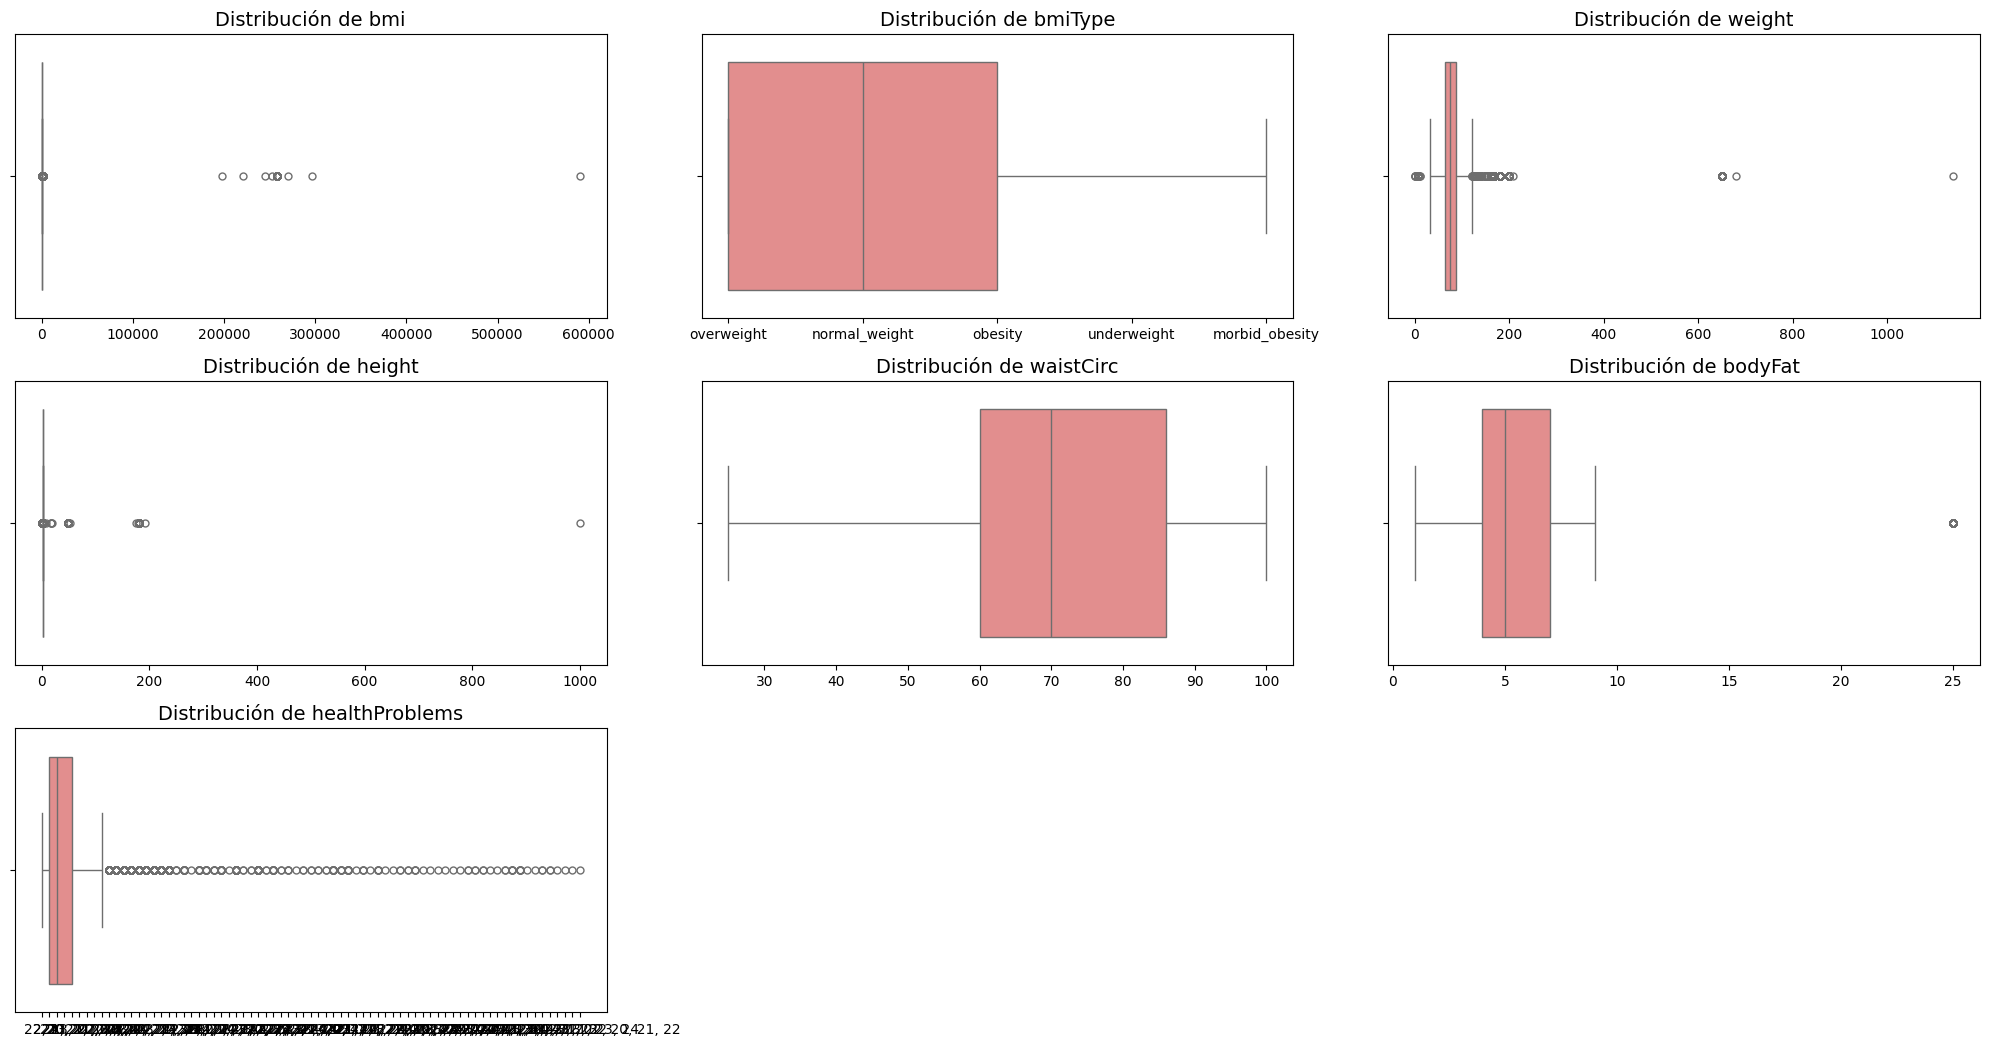

In [ ]:
# Todas las variables numéricas
vars_numericas = [
    'bmi', 'bmiType', 'weight', 'height', 'waistCirc', 'bodyFat', 'healthProblems'
]

plt.figure(figsize=(20, 15))

for i, var in enumerate(vars_numericas):
    plt.subplot(4, 3, i+1)
    if var in df_train.columns:
        sns.boxplot(x=df_train[var], color='lightcoral', fliersize=5)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel('')
    else:
        plt.text(0.5, 0.5, f'{var} no encontrada', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Estado descriptivo de variables categóricas como tipo de IMC, problemas de salud, alergias

In [ ]:
categorical_features = ['bmiType', 'healthProblems', 'allergies', 'diet']
print("=== Tipo de IMC ===")
print(df_train['bmiType'].value_counts())
print("\n=== Problemas de Salud ===")
print(df_train['healthProblems'].value_counts().head(10))
print("\n=== Alergias ===")
print(df_train['allergies'].value_counts().head(10))
print("\n=== Dieta ===")
print(df_train['diet'].value_counts())

=== Tipo de IMC ===
bmiType
normal_weight     25277
overweight        14497
obesity            8328
underweight        3783
morbid_obesity     3269
Name: count, dtype: int64

=== Problemas de Salud ===
healthProblems
21        3646
23        2603
22        1452
21, 22    1147
20         470
20, 22     441
21, 23     364
22, 21     330
21, 24     234
20, 21     124
Name: count, dtype: int64

=== Alergias ===
allergies
2, 12         882
1             815
7             728
3             599
3, 4, 7, 8    330
2, 4, 12      234
3, 7          228
6             224
4, 2, 12      218
3, 5, 7, 8    218
Name: count, dtype: int64

=== Dieta ===
diet
6.0     20841
1.0     13156
25.0     6727
2.0      3091
20.0     1386
21.0      593
23.0      252
22.0       11
Name: count, dtype: int64


### 1.4.4.1 Análisis de outliers (visualización)

El objetivo de esta sección es realizar una auditoría visual detallada de la calidad de los datos. Antes de iniciar el modelado del riesgo cardiovascular, es fundamental detectar los valores atípicos presentes en el dataset, ya que podrían distorsionar el análisis y las predicciones futuras.

Para ello, vamos a representar gráficamente todas las variables dinámicas disponibles:

- **Variables numéricas:** mediante *boxplots*, lo que permite identificar rápidamente valores extremos.
- **Variables categóricas o de frecuencia:** mediante *gráficos de barras*, facilitando la detección de distribuciones anómalas.



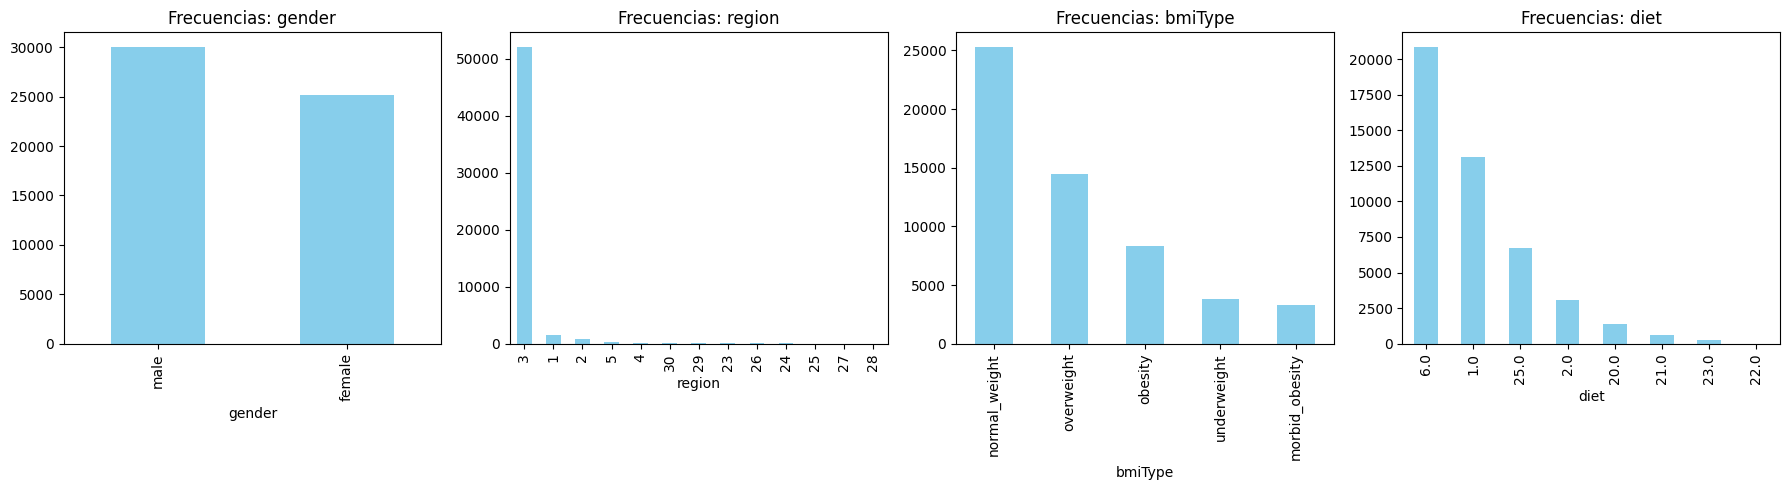

In [ ]:
vars_cat = ['gender', 'region', 'bmiType', 'diet']

plt.figure(figsize=(18, 5))
for i, var in enumerate(vars_cat):
    plt.subplot(1, 4, i+1)
    df_train[var].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Frecuencias: {var}')
plt.tight_layout()
plt.show()

### 1.4.4.2 Tratamiento y corrección de outliers

Una vez identificados los valores atípicos, aplicamos un proceso de corrección orientado a garantizar la coherencia interna del dataset y evitar que estos errores afecten al rendimiento del modelo. Las principales intervenciones realizadas fueron las siguientes:

- **Normalización de la altura (height):** aquí realizamos una mezcla de unidades (metros y centímetros) mediante una transformación condicional. Posteriormente, recortamos los datos a un rango fisiológicamente plausible (1.30–2.40 m) para eliminar valores imposibles.

- **Ajuste del peso (weight):** recortamos los datos al percentil 99 para evitar que valores extremos dañen las distribuciones y los cálculos derivados. Aplicamos un minimo de peso de 45Kg.

- **Recalculado del IMC (BMI):** con pesos y alturas arreglados, recalculamos el IMC y se aplicó un filtro clínico razonable (rango 10–60) para eliminar residuos de errores previos.

- **Corrección de variables de Pasos y Descanso:**  
  - *totalDailySteps* vamos a ajustar los datos al percentil 99, evitando valores imposibles.  
  - *restMinutes* limitamos 11 horas como outlier (660 minutos) y mayor que 0.

Finalmente, vemos la consistencia de las variables corregidas mediante un análisis de mínimos, máximos y medias, confirmando que los valores resultantes se encuentran dentro de rangos realistas y adecuados.


In [ ]:
df_train['height_clean'] = df_train['height'].apply(lambda x: x*100 if x < 0.5 else (x/100 if x > 3 else x))
df_train['height_clean'] = df_train['height_clean'].clip(lower=1.30, upper=2.40)

limit_weight = df_train['weight'].quantile(0.99)
df_train['weight_clean'] = df_train['weight'].clip(lower=45, upper=limit_weight)

df_train['bmi_clean'] = df_train['weight_clean'] / (df_train['height_clean'] ** 2)
df_train['bmi_clean'] = df_train['bmi_clean'].clip(lower=10, upper=60)

limit_steps = df_train['totalDailySteps'].quantile(0.99)
df_train['totalDailySteps_clean'] = df_train['totalDailySteps'].clip(upper=limit_steps)

df_train['restMinutes_clean'] = (df_train['restMinutes']/120).clip(lower=0.01, upper=660)

vars_check = ['height_clean', 'weight_clean','bmi_clean','totalDailySteps_clean', 'restMinutes_clean']
print("--- Visualización de valores posteriores a la corección")
print(df_train[vars_check].agg(['min', 'max', 'mean']).round(2))

--- Visualización de valores posteriores a la corección
      height_clean  weight_clean  bmi_clean  totalDailySteps_clean  \
min           1.30         45.00      10.00                   0.00   
max           2.40        199.58      60.00              188749.00   
mean          1.72         77.81      26.23               21933.41   

      restMinutes_clean  
min                0.01  
max              660.00  
mean             309.27  


In [ ]:
biometric_features = ['weight_clean', 'height_clean', 'bmi_clean', 'waistCirc', 'bodyFat']
df_train[biometric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
weight_clean,55154.0,77.813500,24.122852,45.0,63.000000,74.000000,86.000000,199.582691
height_clean,55154.0,1.716698,0.139102,1.3,1.630000,1.700000,1.800000,2.400000
bmi_clean,55154.0,26.230350,7.016045,10.0,22.222222,24.671053,28.763971,60.000000
waistCirc,50681.0,73.394310,15.982044,25.0,60.000000,70.000000,86.000000,100.000000
bodyFat,50681.0,5.513447,2.535265,1.0,4.000000,5.000000,7.000000,25.000000


En la siguiente gráfica podemos ver de forma muy visual usando missingno las columnas que tienen todos los datos y las que tienen valores perdidos. Además, hay veces que la falta de una variable implica que otra no tenga valor y se puede observar muy fácil algún tipo de patrón con missingno. En este caso no observamos este tipo de patrones.

<Axes: >

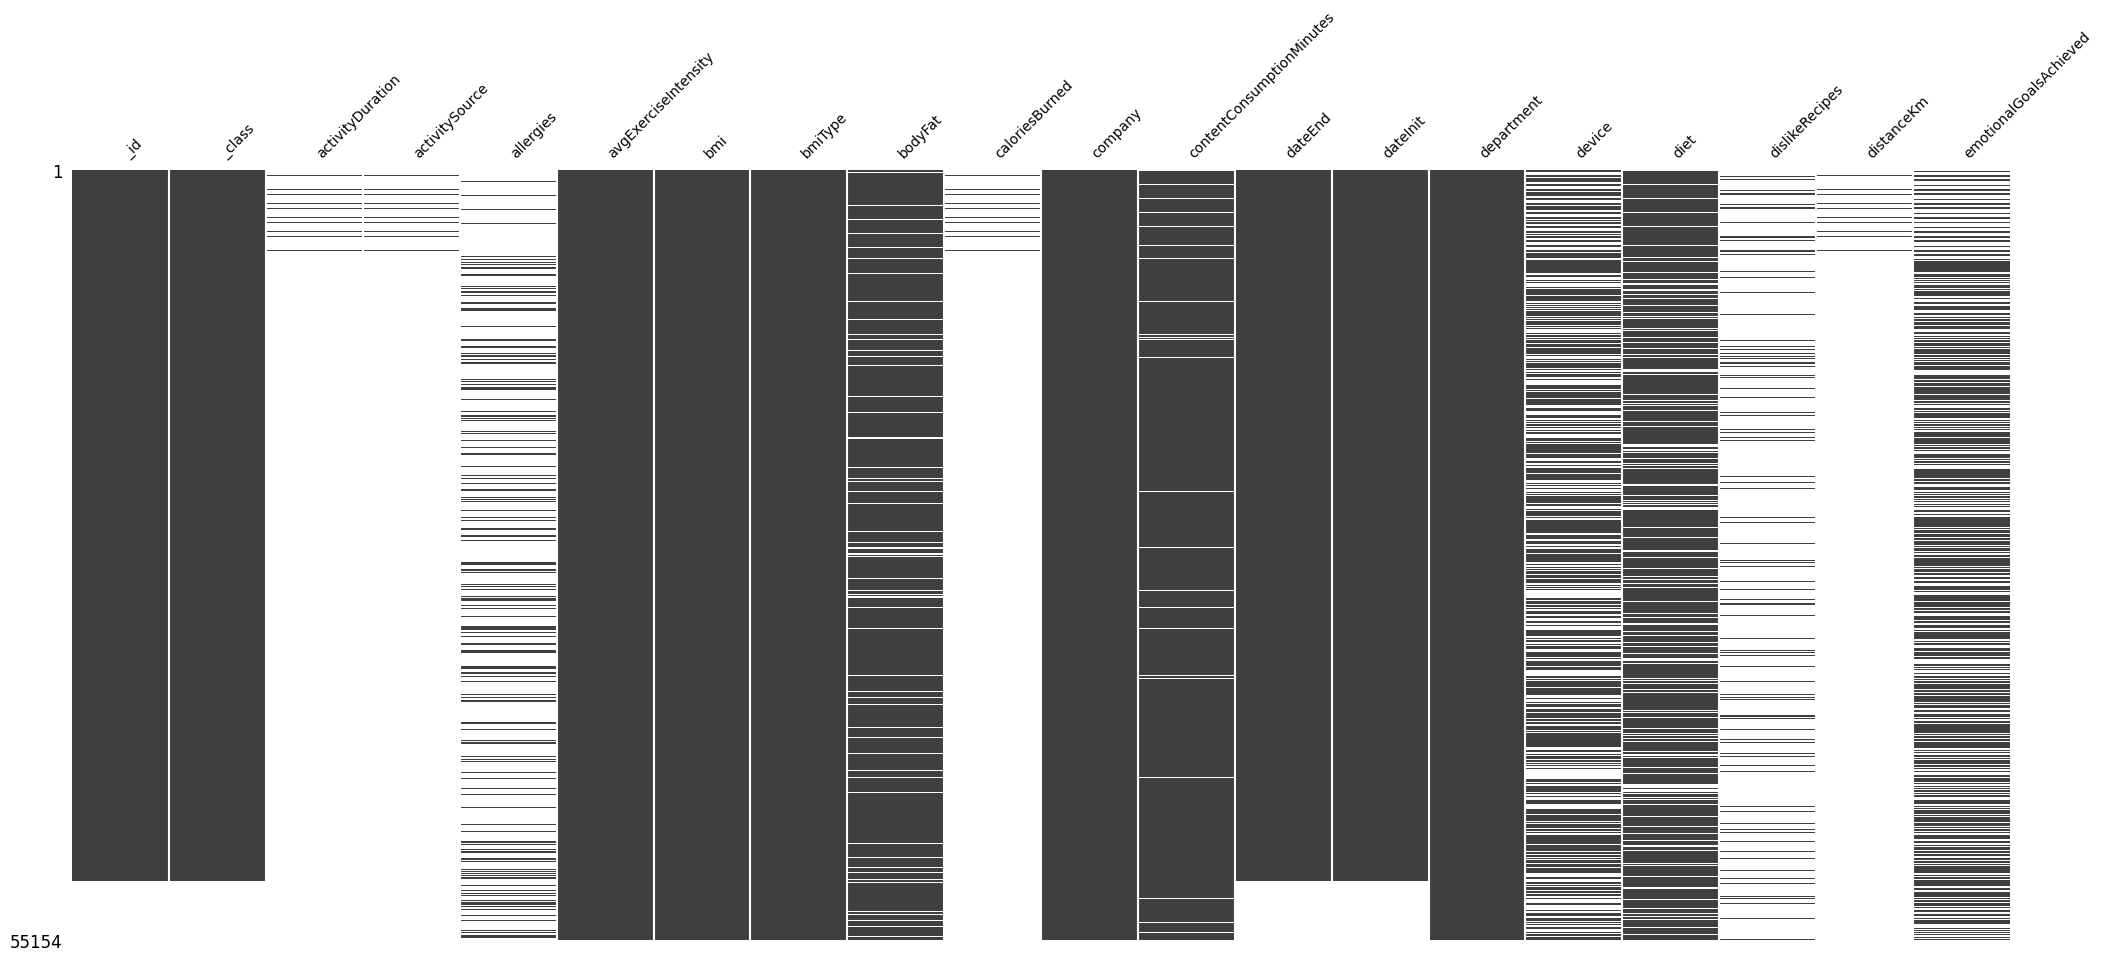

In [ ]:
import missingno as msno
%matplotlib inline
msno.matrix(df_train.iloc[:, :20], fontsize=10, sparkline=False)

También vemos que el número de filas duplicadas es 0, por lo que en este aspecto no será necesario eliminar columnas que repitan datos directamente

In [ ]:
duplicates = df_train.duplicated(subset=['userID', 'dateInit'])
num_duplicates = duplicates.sum()
print(f"Número de registros duplicados por usuario y fecha: {num_duplicates}")
print(f"Datasets únicos (userID): {df_train['userID'].nunique()}")
print(f"Total de registros: {len(df_train)}")

Número de registros duplicados por usuario y fecha: 0
Datasets únicos (userID): 4668
Total de registros: 55154


#### Corrección de `height`: normalización de unidades

Se detecta que `height` mezcla dos escalas: la mayoría de valores están en metros (rango 1.5–1.9 m), pero existe una minoría de registros en centímetros (valores >3). Se aplica la siguiente regla de normalización:
- Si `height` > 3 → se divide entre 100 (conversión cm → m)
- Valores ≤ 3 → se mantienen como están

Tras la corrección se recalcula el IMC (`bmi`) para los registros afectados.

In [ ]:
# --- Corrección de unidades de height sobre la variable limpia ---
mask_cm = df_train['height_clean'] > 3
n_affected = mask_cm.sum()
print(f"Registros con height_clean en cm (>3 m): {n_affected} ({n_affected/len(df_train)*100:.2f}%)")

df_train.loc[mask_cm, 'height_clean'] = df_train.loc[mask_cm, 'height_clean'] / 100

# Recalcular BMI limpio para los registros corregidos
mask_valid = mask_cm & df_train['weight_clean'].notna() & (df_train['height_clean'] > 0)
df_train.loc[mask_valid, 'bmi_clean'] = (
    df_train.loc[mask_valid, 'weight_clean'] / (df_train.loc[mask_valid, 'height_clean'] ** 2)
)

print(f"\nEstadísticas de height_clean tras corrección:")
print(df_train['height_clean'].describe())

print(f"\nEstadísticas de bmi_clean tras corrección:")
print(df_train['bmi_clean'].describe())

# Verificación: no deben quedar valores fuera del rango humano razonable
outliers_height = df_train[
    (df_train['height_clean'] < 1.0) | (df_train['height_clean'] > 2.5)
]
print(f"\nRegistros con height_clean fuera de rango [1.0, 2.5] m tras corrección: {len(outliers_height)}")

Registros con height_clean en cm (>3 m): 0 (0.00%)

Estadísticas de height_clean tras corrección:
count    55154.000000
mean         1.716698
std          0.139102
min          1.300000
25%          1.630000
50%          1.700000
75%          1.800000
max          2.400000
Name: height_clean, dtype: float64

Estadísticas de bmi_clean tras corrección:
count    55154.000000
mean        26.230350
std          7.016045
min         10.000000
25%         22.222222
50%         24.671053
75%         28.763971
max         60.000000
Name: bmi_clean, dtype: float64

Registros con height_clean fuera de rango [1.0, 2.5] m tras corrección: 0


In [ ]:
df_train[['height_clean', 'bmi_clean']].head(10)

,height_clean,bmi_clean
0,1.81,25.029761
1,1.85,25.127831
2,1.63,24.088223
3,1.80,22.222222
4,1.59,20.173253
5,1.70,23.529412
6,1.53,33.747704
7,1.80,24.382716
8,1.30,39.053254
9,1.59,19.382145


In [ ]:
print("=== Género ===")
print(df_train['gender'].value_counts())
print("\n=== Empresas ===")
print(df_train['company'].value_counts())
print("\n=== Departamentos ===")
print(df_train['department'].value_counts())
print("\n=== Regiones ===")
print(df_train['region'].value_counts())

=== Género ===
gender
male      30006
female    25148
Name: count, dtype: int64

=== Empresas ===
company
47    44712
1      6205
48     1181
77      830
43      283
79      275
62      270
56      180
92      151
45      136
76      135
85      134
57      119
52       99
50       82
51       73
40       69
83       58
55       46
84       43
80       31
88       17
75       14
3        11
Name: count, dtype: int64

=== Departamentos ===
department
146     7236
154     3780
144     3780
132     3456
157     3348
        ... 
518        1
405        1
497        1
473        1
3571       1
Name: count, Length: 276, dtype: int64

=== Regiones ===
region
3     52020
1      1536
2       803
5       240
4       147
30      133
29       53
23       52
26       51
24       50
25       34
27       24
28       11
Name: count, dtype: int64


### 1.4.5 Variables de actividad física

Estas variables miden movimiento y ejercicio durante el periodo analizado.

- Pasos totales: `totalDailySteps`
- Distancia recorrida: `distanceKm`
- Calorias quemadas: `caloriesBurned`
- Duracion del entrenamiento: `activityDuration`
- Sesiones de actividad fisica: `physicalActivitySesions`
- Usuario fisicamente activo (binaria): `physicallyActiveFlag`
- Intensidad promedio (categorica): `avgExerciseIntensity`
- Adherencia a actividad fisica: `fitnessPlanAdherence`

Se detecta que la variable *physicallyActiveFlag* no recoge bien los datos y se acuerca quitarla del modelo.

In [ ]:
df_train = df_train.drop(columns=['physicallyActiveFlag'], errors='ignore')

In [ ]:
activity_features_num = [
    'totalDailySteps_clean', 'distanceKm', 'caloriesBurned',
    'activityDuration', 'physicalActivitySesions', 'fitnessPlanAdherence'
]

print("=== Estadísticas de Actividad Física (numéricas) ===")
for feature in activity_features_num:
    if feature in df_train.columns:
        s = pd.to_numeric(df_train[feature], errors='coerce')
        print(f"\n{feature}:")
        print(f"  Media: {s.mean():.2f}")
        print(f"  Min: {s.min():.2f}")
        print(f"  Max: {s.max():.2f}")
        print(f"  Valores missing: {s.isna().sum()}")

print("\n=== avgExerciseIntensity (categórica) ===")
print(df_train['avgExerciseIntensity'].value_counts(dropna=False))

=== Estadísticas de Actividad Física (numéricas) ===

totalDailySteps_clean:
  Media: 21933.41
  Min: 0.00
  Max: 188749.00
  Valores missing: 52671

distanceKm:
  Media: 4.87
  Min: 0.00
  Max: 1319.00
  Valores missing: 54380

caloriesBurned:
  Media: 629.58
  Min: 0.00
  Max: 167728.00
  Valores missing: 54380

activityDuration:
  Media: 15210.52
  Min: 1.00
  Max: 357134.00
  Valores missing: 54380

physicalActivitySesions:
  Media: 0.01
  Min: 0.00
  Max: 72.00
  Valores missing: 0

fitnessPlanAdherence:
  Media: 5.44
  Min: 1.00
  Max: 31.00
  Valores missing: 54380

=== avgExerciseIntensity (categórica) ===
avgExerciseIntensity
moderate        18207
light           14776
sedentary       13642
intense          5921
very_intense     2608
Name: count, dtype: int64


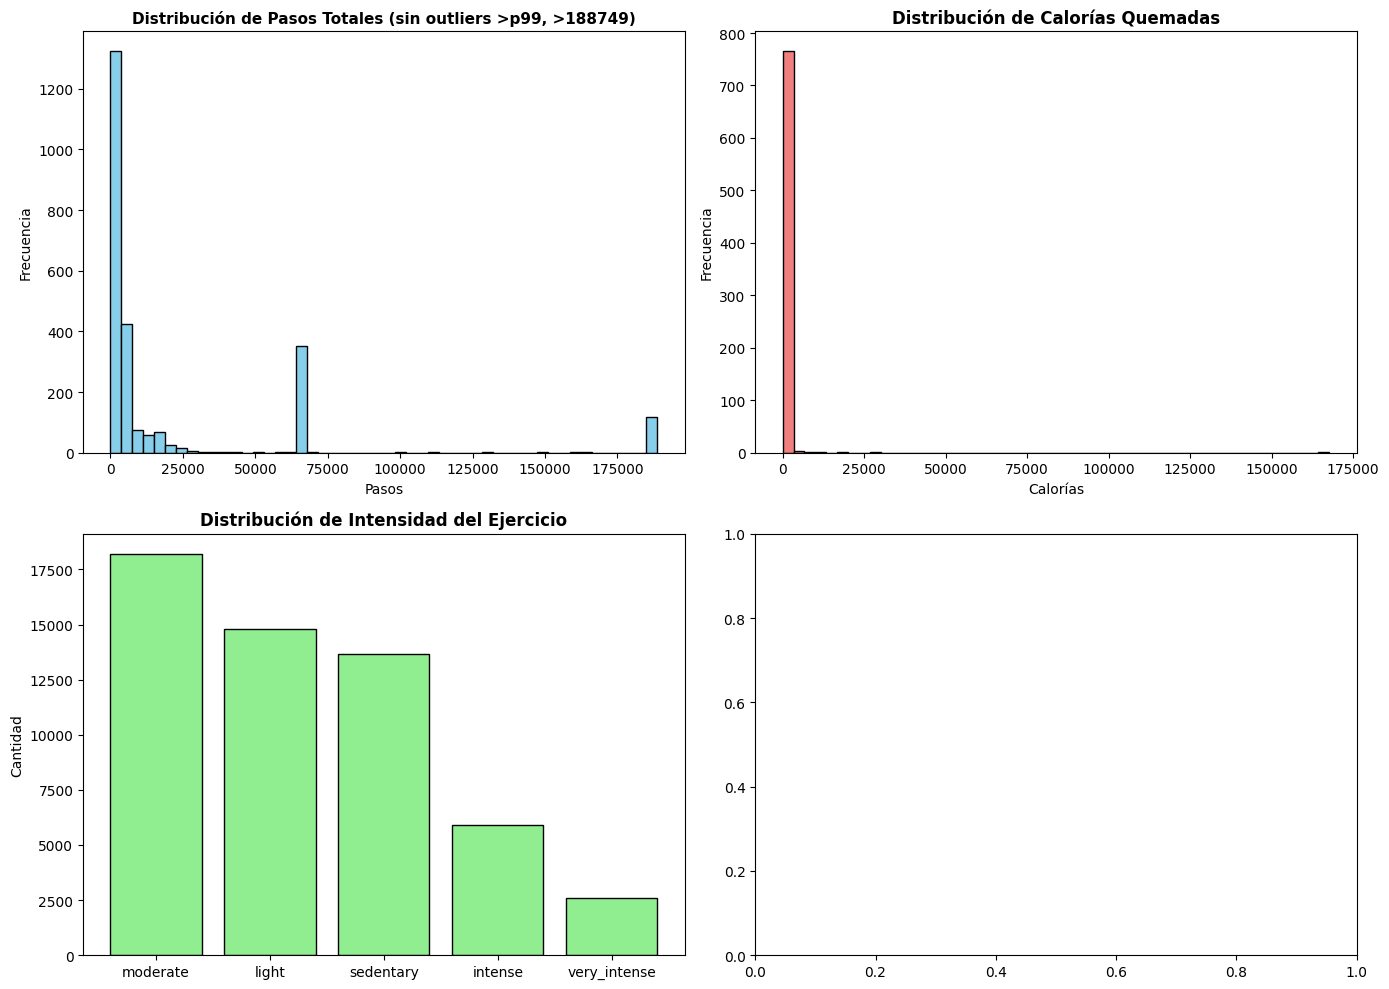

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pasos totales (usar variable ya limpiada)
steps_clean = pd.to_numeric(df_train['totalDailySteps_clean'], errors='coerce').dropna()
steps_upper = df_train['totalDailySteps_clean'].quantile(0.99)

axes[0, 0].hist(steps_clean, bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title(
    f'Distribución de Pasos Totales (sin outliers >p99, >{steps_upper:.0f})',
    fontsize=11, fontweight='bold'
)
axes[0, 0].set_xlabel('Pasos')
axes[0, 0].set_ylabel('Frecuencia')

# Calorías quemadas
axes[0, 1].hist(df_train['caloriesBurned'].dropna(), bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribución de Calorías Quemadas', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Calorías')
axes[0, 1].set_ylabel('Frecuencia')

# Intensidad del ejercicio
intensity_counts = df_train['avgExerciseIntensity'].value_counts()
axes[1, 0].bar(intensity_counts.index, intensity_counts.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribución de Intensidad del Ejercicio', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


### 1.4.6 Variables de descanso

El descanso y la calidad del suenio se consideran factores relevantes en salud cardiovascular.

- Minutos de descanso: `restMinutes`
- Objetivo de descanso: `sleepGoal`
- Dias con descanso: `sleepDays`

In [ ]:
print("=== Variables de descanso ===")
rest_cols = ['restMinutes_clean', 'sleepGoal', 'sleepDays']
for col in rest_cols:
    if col in df_train.columns:
        s = pd.to_numeric(df_train[col], errors='coerce')
        print(f"\n{col}")
        print(f"  no nulos: {s.notna().sum()} | nulos: {s.isna().sum()} ({(s.isna().mean()*100):.2f}%)")
        print(s.describe())

=== Variables de descanso ===

restMinutes_clean
  no nulos: 1556 | nulos: 53598 (97.18%)
count    1556.000000
mean      309.272930
std       320.589409
min         0.010000
25%         0.010000
50%         5.291667
75%       660.000000
max       660.000000
Name: restMinutes_clean, dtype: float64

sleepGoal
  no nulos: 55154 | nulos: 0 (0.00%)
count    55154.000000
mean       475.882728
std         21.532474
min          1.000000
25%        480.000000
50%        480.000000
75%        480.000000
max        490.000000
Name: sleepGoal, dtype: float64

sleepDays
  no nulos: 1556 | nulos: 53598 (97.18%)
count    1556.000000
mean        4.508997
std         6.249521
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        31.000000
Name: sleepDays, dtype: float64


### 1.4.7 Variables de nutrición

Estas variables permiten analizar habitos alimentarios y su relacion con salud metabolica.

- Dieta: `diet`
- Alergias: `allergies`
- Adherencia nutricional: `nutritionPlanAdherence`
- Gasto energetico estimado: `foodEnergyExpenditure`

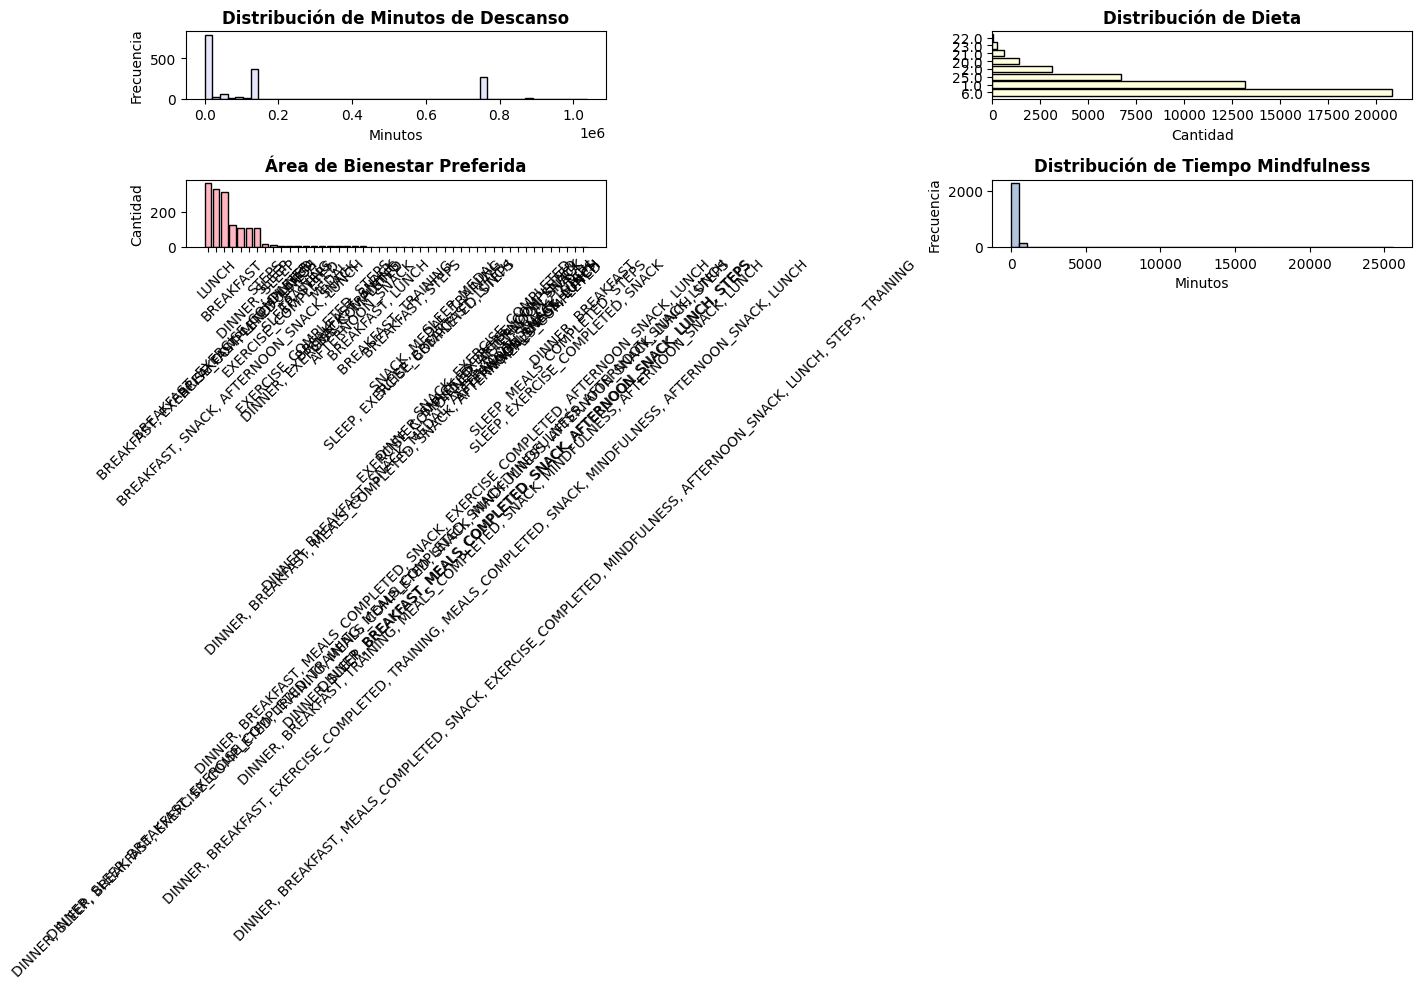

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Minutos de descanso
axes[0, 0].hist(df_train['restMinutes'].dropna(), bins=50, color='lavender', edgecolor='black')
axes[0, 0].set_title('Distribución de Minutos de Descanso', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Minutos')
axes[0, 0].set_ylabel('Frecuencia')

# Dieta
diet_counts = df_train['diet'].value_counts()
axes[0, 1].barh(range(len(diet_counts)), diet_counts.values, color='lightyellow', edgecolor='black')
axes[0, 1].set_yticks(range(len(diet_counts)))
axes[0, 1].set_yticklabels(diet_counts.index)
axes[0, 1].set_title('Distribución de Dieta', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cantidad')

# Preferencia de bienestar
wellness_counts = df_train['preferredWellnessArea'].value_counts()
axes[1, 0].bar(range(len(wellness_counts)), wellness_counts.values, color='lightpink', edgecolor='black')
axes[1, 0].set_xticks(range(len(wellness_counts)))
axes[1, 0].set_xticklabels(wellness_counts.index, rotation=45)
axes[1, 0].set_title('Área de Bienestar Preferida', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Cantidad')

# Tiempo mindfulness
axes[1, 1].hist(df_train['mindfulnessTime'].dropna(), bins=50, color='lightsteelblue', edgecolor='black')
axes[1, 1].set_title('Distribución de Tiempo Mindfulness', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Minutos')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 1.4.8 Variables de bienestar emocional

Estas variables permiten analizar participacion en actividades de bienestar psicologico.

- Tiempo mindfulness: `mindfulnessTime`
- Metas emocionales cumplidas: `emotionalGoalsAchieved`
- Talleres emocionales: `emotionalWorkshopEnrollments`
- Area de bienestar preferida: `preferredWellnessArea`

In [ ]:
print("=== Variables de bienestar emocional ===")

for col in ['mindfulnessTime', 'emotionalGoalsAchieved', 'emotionalWorkshopEnrollments']:
    if col in df_train.columns:
        s = pd.to_numeric(df_train[col], errors='coerce')
        print(f"\n{col}")
        print(f"  no nulos: {s.notna().sum()} | nulos: {s.isna().sum()} ({(s.isna().mean()*100):.2f}%)")
        print(s.describe())

print("\nArea de bienestar preferida (frecuencias):")
print(df_train['preferredWellnessArea'].value_counts(dropna=False).head(15))

=== Variables de bienestar emocional ===

mindfulnessTime
  no nulos: 2409 | nulos: 52745 (95.63%)
count     2409.000000
mean        85.211706
std        638.827491
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      25616.000000
Name: mindfulnessTime, dtype: float64

emotionalGoalsAchieved
  no nulos: 32619 | nulos: 22535 (40.86%)
count    32619.000000
mean         0.010975
std          0.539394
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.000000
Name: emotionalGoalsAchieved, dtype: float64

emotionalWorkshopEnrollments
  no nulos: 55154 | nulos: 0 (0.00%)
count    55154.000000
mean         0.002883
std          0.137882
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         12.000000
Name: emotionalWorkshopEnrollments, dtype: float64

Area de bienestar preferida (frecuencias):
preferredWellnessArea
NaN                                     

In [ ]:
print("=== Variables de nutricion ===")

print("\nDieta (frecuencias):")
print(df_train['diet'].value_counts(dropna=False).head(15))

print("\nAlergias (frecuencias):")
print(df_train['allergies'].value_counts(dropna=False).head(15))

for col in ['nutritionPlanAdherence', 'foodEnergyExpenditure']:
    if col in df_train.columns:
        s = pd.to_numeric(df_train[col], errors='coerce')
        print(f"\n{col}")
        print(f"  no nulos: {s.notna().sum()} | nulos: {s.isna().sum()} ({(s.isna().mean()*100):.2f}%)")
        print(s.describe())

=== Variables de nutricion ===

Dieta (frecuencias):
diet
6.0     20841
1.0     13156
NaN      9097
25.0     6727
2.0      3091
20.0     1386
21.0      593
23.0      252
22.0       11
Name: count, dtype: int64

Alergias (frecuencias):
allergies
NaN           44823
2, 12           882
1               815
7               728
3               599
3, 4, 7, 8      330
2, 4, 12        234
3, 7            228
6               224
4, 2, 12        218
3, 5, 7, 8      218
7, 7            217
1, 7            135
2               129
14              123
Name: count, dtype: int64

nutritionPlanAdherence
  no nulos: 32619 | nulos: 22535 (40.86%)
count    32619.000000
mean         0.014654
std          0.583906
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.000000
Name: nutritionPlanAdherence, dtype: float64

foodEnergyExpenditure
  no nulos: 46057 | nulos: 9097 (16.49%)
count     46057.000000
mean       3753.669722
std       15539.744924
min      

### Resumen del EDA: Estado de Variables del Dataset Wellat

| Categoría | Variables | Valores Perdidos | Distribución |
| :--- | :--- | :--- | :--- |
| **Demográficas** | Edad, Género, Región, Empresa, Depto | Verificar | Balanceada |
| **Biométricas** | IMC, Peso, Altura, Cintura, Grasa corporal | Algunos | Normal |
| **Actividad Física** | Pasos, Distancia, Calorías, Sesiones, Intensidad | Varios | Variable |
| **Descanso** | Minutos, Objetivo, Días | Algunos | Variable |
| **Nutrición** | Dieta, Alergias, Adherencia, Energía | Verificar | Mixed |
| **Bienestar Emocional** | Mindfulness, Metas, Talleres | Algunos | Variable |

### Matriz de correlación (solo variables numéricas originales)

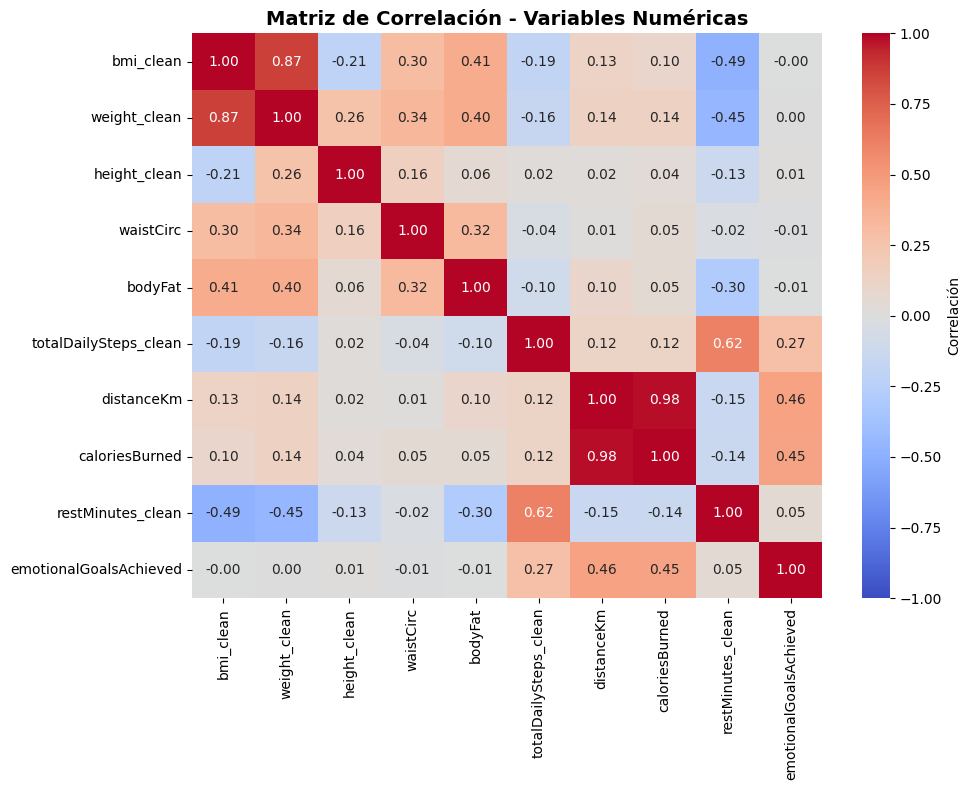

In [ ]:
numerical_cols = [
    'bmi_clean', 'weight_clean', 'height_clean', 'waistCirc', 'bodyFat', 'totalDailySteps_clean',
    'distanceKm', 'caloriesBurned', 'restMinutes_clean', 'emotionalGoalsAchieved'
]

available_cols = [
    col for col in numerical_cols
    if col in df_train.columns and df_train[col].dtype in ['int64', 'float64']
]

correlation_matrix = df_train[available_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlación'}, vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.5 Problemas de calidad de datos identificados

Durante el EDA se han detectado los siguientes problemas de calidad que deben tenerse en cuenta en el diseño del pipeline:

### Outliers en variables biométricas

**`weight`**: rango observado 7–651 kg. Valores fuera del rango clínicamente razonable (30–250 kg) son probablemente errores de entrada. No se eliminan en esta fase, pero deberán tratarse en el pipeline antes del modelado.

**`bmi`**: tras la corrección de `height`, se recalcula para los registros afectados. Conviene verificar que no persistan valores extremos (>60 o <10) que indiquen errores residuales en `weight`.

**`waistCirc`**: el máximo observado es exactamente 100 cm, lo que sugiere un posible truncamiento artificial del valor real en el sistema de origen. Los registros con valor 100 deben tratarse con cautela.

### Variables con varianza cero o casi cero

Las siguientes variables no aportan información discriminativa y deben excluirse del pipeline de modelado:

- **`emotionalGoalsAchieved`**: todos los valores no nulos son 0.0 — varianza cero.
- **`fitnessPlanAdherence`**: todos los valores no nulos son 1.0 — varianza cero.
- **`nutritionPlanAdherence`**: media ~0.001, prácticamente constante a cero.

### Escala dudosa en `bodyFat`

Los valores van de 1 a 25 con media ~5.5. Para adultos en entorno corporativo, una media de 5.5% de grasa corporal es clínicamente inviable. Es probable que la variable esté codificada como una escala ordinal (categorías 1–25) y no como porcentaje real. Debe confirmarse la definición original antes de usarla como feature en el modelo.

### Coherencia entre `bmiType` y `bmi`

`bmiType` es una categorización derivada de `bmi`. Al haberse corregido `height` y recalculado `bmi` para una parte de los registros, existe riesgo de inconsistencia entre ambas variables. En el pipeline se recomienda recalcular `bmiType` a partir del `bmi` corregido en lugar de usar el valor original.

In [ ]:
# Verificación de bmi tras corrección de height
print("=== BMI tras corrección de height ===")
bmi_outliers = df_train[(df_train['bmi'] > 60) | (df_train['bmi'] < 10)]
print(f"Registros con bmi fuera de rango [10, 60]: {len(bmi_outliers)} ({len(bmi_outliers)/len(df_train)*100:.2f}%)")
print(df_train['bmi'].describe())

# Verificación de weight
print("\n=== Weight: outliers fuera de rango [30, 250] kg ===")
weight_outliers = df_train[(df_train['weight'] < 30) | (df_train['weight'] > 250)]
print(f"Registros afectados: {len(weight_outliers)} ({len(weight_outliers)/len(df_train)*100:.2f}%)")

# Verificación de waistCirc truncado
print("\n=== waistCirc == 100 (posible truncamiento) ===")
print(f"Registros con waistCirc = 100: {(df_train['waistCirc'] == 100).sum()}")

# Varianza de variables problemáticas
print("\n=== Varianza de variables casi constantes ===")
for col in ['emotionalGoalsAchieved', 'fitnessPlanAdherence', 'nutritionPlanAdherence']:
    if col in df_train.columns:
        print(f"{col}: std={df_train[col].std():.4f}, nunique={df_train[col].nunique()}")

# bodyFat: distribución de valores únicos
print("\n=== bodyFat: valores únicos ===")
print(df_train['bodyFat'].value_counts().sort_index())

# Coherencia bmiType vs bmi
print("\n=== Coherencia bmiType vs bmi ===")
def expected_bmi_type(bmi):
    if bmi < 18.5: return 'underweight'
    elif bmi < 25: return 'normal'
    elif bmi < 30: return 'overweight'
    else: return 'obese'

check = df_train[df_train['bmi'].notna() & df_train['bmiType'].notna()].copy()
check['expected_bmiType'] = check['bmi'].apply(expected_bmi_type)
mismatch = check[check['bmiType'].str.lower() != check['expected_bmiType']]
print(f"Registros con bmiType inconsistente con bmi: {len(mismatch)} ({len(mismatch)/len(check)*100:.2f}%)")
if len(mismatch) > 0:
    print(mismatch[['userID','bmi','bmiType','expected_bmiType']].head(10))

=== BMI tras corrección de height ===
Registros con bmi fuera de rango [10, 60]: 2639 (4.78%)
count     55154.000000
mean        578.364161
std       11972.509840
min           0.000000
25%          22.512500
50%          24.910000
75%          29.065927
max      590000.000000
Name: bmi, dtype: float64

=== Weight: outliers fuera de rango [30, 250] kg ===
Registros afectados: 225 (0.41%)

=== waistCirc == 100 (posible truncamiento) ===
Registros con waistCirc = 100: 5620

=== Varianza de variables casi constantes ===
emotionalGoalsAchieved: std=0.5394, nunique=10
fitnessPlanAdherence: std=4.3006, nunique=15
nutritionPlanAdherence: std=0.5839, nunique=14

=== bodyFat: valores únicos ===
bodyFat
1.0       780
2.0      2815
3.0      4911
4.0      7922
5.0     10975
6.0      8824
7.0      6354
8.0      4489
9.0      3243
25.0      368
Name: count, dtype: int64

=== Coherencia bmiType vs bmi ===
Registros con bmiType inconsistente con bmi: 39388 (71.41%)
    userID         bmi         bmiTy

## 2. Conclusiones del EDA por tipología

### Hallazgos principales

1. **Demograficas**: La distribucion por genero es relativamente equilibrada, pero region y empresa muestran fuerte concentracion en pocas categorias.
2. **Biometricas**: IMC, peso, altura y cintura permiten caracterizar perfil fisico base, aunque hay presencia de outliers que deben revisarse antes de modelar.
3. **Actividad fisica**: `avgExerciseIntensity` se confirma como variable categorica; las variables de actividad continua tienen alta ausencia y deben analizarse con submuestras `notna`.
4. **Descanso**: `restMinutes`, `sleepGoal` y `sleepDays` presentan ausencia extrema, por lo que su interpretacion global es limitada.

5. **Nutricion**: `diet` y `allergies` son utiles para segmentacion, pero la cobertura es parcial; `nutritionPlanAdherence` y `foodEnergyExpenditure` requieren control de missing.Conclusion metodologica: el dataset combina variables densas de perfil base con variables event-driven muy dispersas, por lo que el analisis debe reportar siempre cobertura efectiva por variable.

6. **Bienestar emocional**: `mindfulnessTime`, `emotionalGoalsAchieved` y `emotionalWorkshopEnrollments` presentan baja cobertura; reflejan uso puntual de funcionalidades.

In [ ]:
tmp = df_train.copy()
tmp['date_day'] = pd.to_datetime(tmp['dateInit'], errors='coerce').dt.date

print('Filas totales:', len(tmp))
print('Usuarios unicos:', tmp['userID'].nunique())
print('Dias unicos en dataset:', tmp['date_day'].nunique())
print('Combinaciones unicas userID-date:', tmp[['userID','date_day']].drop_duplicates().shape[0])
print('Duplicados exactos userID-date:', tmp.duplicated(subset=['userID','date_day']).sum())

reg_por_usuario = tmp.groupby('userID').size()
print('\nRegistros por usuario (resumen):')
print(reg_por_usuario.describe())

rango_fechas = tmp.groupby('userID')['date_day'].agg(['min','max','nunique']).head()
print('\nEjemplo de rango temporal por usuario (5 primeros):')
print(rango_fechas)

Filas totales: 55154
Usuarios unicos: 4668
Dias unicos en dataset: 365
Combinaciones unicas userID-date: 55154
Duplicados exactos userID-date: 0

Registros por usuario (resumen):
count    4668.000000
mean       11.815338
std        37.165175
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       365.000000
dtype: float64

Ejemplo de rango temporal por usuario (5 primeros):
               min         max  nunique
userID                                 
1              NaN         NaN        0
3       2025-01-01  2025-12-31      365
35      2025-01-01  2025-12-31      365
50      2025-01-01  2025-12-31      365
92      2025-01-01  2025-12-31      365


In [ ]:
datos_agrupados_userid = (
    df_train
    .groupby('userID')
    .agg(
        num_registros=('userID', 'size'),
        fecha_min=('dateInit', 'min'),
        fecha_max=('dateInit', 'max')
    )
    .reset_index()
    .sort_values('num_registros', ascending=False)
)

datos_agrupados_userid.head(10)

,userID,num_registros,fecha_min,fecha_max
2935,7204,365,2025-01-01 00:00:00,2025-12-31 00:00:00
762,1986,365,2025-01-01 00:00:00,2025-12-31 00:00:00
4612,12237,365,2025-01-01 00:00:00,2025-12-31 00:00:00
4613,12240,365,2025-01-01 00:00:00,2025-12-31 00:00:00
4614,12241,365,2025-01-01 00:00:00,2025-12-31 00:00:00
4311,11035,365,2025-01-01 00:00:00,2025-12-31 00:00:00
4052,10679,365,2025-01-01 00:00:00,2025-12-31 00:00:00
3,50,365,2025-01-01 00:00:00,2025-12-31 00:00:00
2,35,365,2025-01-01 00:00:00,2025-12-31 00:00:00
1,3,365,2025-01-01 00:00:00,2025-12-31 00:00:00


In [ ]:
# Número de usuarios únicos en el dataset
num_usuarios_unicos = df_train['userID'].nunique()
print(f"Número de usuarios únicos en el dataset: {num_usuarios_unicos}")

# Información adicional sobre la distribución de usuarios
print(f"\nTotal de registros: {len(df_train)}")
print(f"Promedio de registros por usuario: {len(df_train) / num_usuarios_unicos:.2f}")

# Top 10 usuarios con más registros
top_usuarios = df_train['userID'].value_counts().head(10)
print(f"\nTop 10 usuarios con más registros:")
print(top_usuarios)
tail_usuarios = df_train['userID'].value_counts().tail(10)
print(f"\nTop 10 usuarios con menos registros:")
print(tail_usuarios)

Número de usuarios únicos en el dataset: 4668

Total de registros: 55154
Promedio de registros por usuario: 11.82

Top 10 usuarios con más registros:
userID
7204     365
3551     365
12241    365
12240    365
11664    365
11035    365
1986     365
541      365
92       365
50       365
Name: count, dtype: int64

Top 10 usuarios con menos registros:
userID
3189    1
3202    1
3200    1
3198    1
3194    1
823     1
3192    1
3191    1
3190    1
3203    1
Name: count, dtype: int64


## 3. Agregación temporal de datos (mensual)

Dado que el dataset esta a nivel usuario-dia y contiene muchas variables con ausencia por no uso diario,
se construye una vista agregada mensual para:

- Reducir ruido diario.
- Mejorar interpretabilidad de patrones.
- Diferenciar valores bajos reales de falta de registro mediante metricas de cobertura.

In [ ]:
# Construccion de dataset mensual por usuario
monthly = df_train.copy()
monthly['date_day'] = pd.to_datetime(monthly['dateInit'], errors='coerce')
monthly = monthly.dropna(subset=['date_day']).copy()
monthly['year_month'] = monthly['date_day'].dt.to_period('M').astype(str)

# Columnas numericas de interes (ajusta si quieres ampliar/reducir)
num_cols = [
    'bmi_clean', 'weight_clean', 'height_clean', 'waistCirc', 'bodyFat',
    'totalDailySteps_clean', 'distanceKm', 'caloriesBurned', 'activityDuration',
    'physicalActivitySesions', 'fitnessPlanAdherence',
    'restMinutes_clean', 'sleepGoal', 'sleepDays',
    'nutritionPlanAdherence', 'foodEnergyExpenditure',
    'mindfulnessTime', 'emotionalGoalsAchieved', 'emotionalWorkshopEnrollments'
]
num_cols = [c for c in num_cols if c in monthly.columns]
for c in num_cols:
    monthly[c] = pd.to_numeric(monthly[c], errors='coerce')

# Agregados numericos mensuales por usuario
agg_num = monthly.groupby(['userID', 'year_month'])[num_cols].agg(['mean', 'sum'])
agg_num.columns = [f"{col}_{stat}" for col, stat in agg_num.columns]
agg_num = agg_num.reset_index()

# Cobertura de registro mensual (porcentaje de dias con dato)
coverage_cols = ['totalDailySteps_clean', 'restMinutes_clean', 'mindfulnessTime', 'caloriesBurned', 'distanceKm']
coverage_cols = [c for c in coverage_cols if c in monthly.columns]
coverage = monthly.groupby(['userID', 'year_month'])[coverage_cols].apply(lambda g: g.notna().mean())
coverage = coverage.rename(columns={c: f"coverage_{c}" for c in coverage_cols}).reset_index()

# Categóricas mensuales por moda (si existen)
cat_cols = ['gender', 'region', 'company', 'department', 'bmiType', 'diet', 'avgExerciseIntensity', 'preferredWellnessArea']
cat_cols = [c for c in cat_cols if c in monthly.columns]

if cat_cols:
    def safe_mode(s):
        m = s.mode(dropna=True)
        return m.iloc[0] if not m.empty else np.nan

    agg_cat = monthly.groupby(['userID', 'year_month'])[cat_cols].agg(safe_mode).reset_index()
else:
    agg_cat = monthly[['userID', 'year_month']].drop_duplicates().copy()

# Merge final usuario-mes
df_user_month = agg_num.merge(coverage, on=['userID', 'year_month'], how='left')
df_user_month = df_user_month.merge(agg_cat, on=['userID', 'year_month'], how='left')

print('Dataset mensual por usuario creado')
print('Dimensiones:', df_user_month.shape)
print(df_user_month.head(10))

Dataset mensual por usuario creado
Dimensiones: (1860, 53)
   userID year_month  bmi_clean_mean  bmi_clean_sum  weight_clean_mean  \
0       3    2025-01       25.029761     775.922591               82.0   
1       3    2025-02       25.029761     700.833308               82.0   
2       3    2025-03       25.029761     775.922591               82.0   
3       3    2025-04       25.029761     750.892830               82.0   
4       3    2025-05       25.029761     775.922591               82.0   
5       3    2025-06       25.029761     750.892830               82.0   
6       3    2025-07       25.029761     775.922591               82.0   
7       3    2025-08       25.029761     775.922591               82.0   
8       3    2025-09       25.029761     750.892830               82.0   
9       3    2025-10       25.029761     775.922591               82.0   

   weight_clean_sum  height_clean_mean  height_clean_sum  waistCirc_mean  \
0            2542.0               1.81            

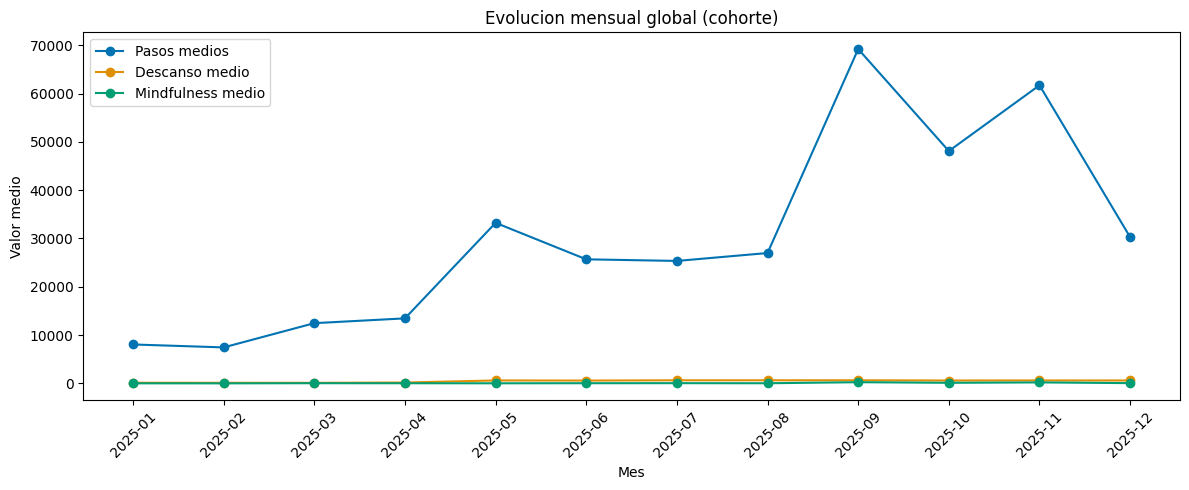

In [ ]:
# Vista global mensual (cohorte)
global_month = monthly.groupby('year_month')[num_cols].mean().reset_index()

plt.figure(figsize=(12, 5))
if 'totalDailySteps_clean' in global_month.columns:
    plt.plot(global_month['year_month'], global_month['totalDailySteps_clean'], marker='o', label='Pasos medios')
if 'restMinutes_clean' in global_month.columns:
    plt.plot(global_month['year_month'], global_month['restMinutes_clean'], marker='o', label='Descanso medio')
if 'mindfulnessTime' in global_month.columns:
    plt.plot(global_month['year_month'], global_month['mindfulnessTime'], marker='o', label='Mindfulness medio')

plt.xticks(rotation=45)
plt.title('Evolucion mensual global (cohorte)')
plt.xlabel('Mes')
plt.ylabel('Valor medio')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Agregación de datos a nivel usuario

Dado que el dataset esta a nivel usuario-dia y contiene muchas variables con ausencia por no uso diario, y el clustering necesita una observación por individuo, vamos a **transformar** el dataset y eliminar columnas que no se usarán

In [ ]:
df = df_train.drop(columns=['_id', '_class','dateEnd'], errors='ignore').copy()

user_col = 'userID'
date_col = 'dateInit'  # no se agregará al dataset final

columnas_base = [c for c in df.columns if c not in [user_col, date_col]]

resultados = []

for var in columnas_base:
    serie = df[var]

    # usuarios con al menos un dato en esa variable
    variability = df[df[var].notna()].groupby(user_col)[var].nunique(dropna=True)

    if len(variability) == 0:
        tipo = 'SIN_DATOS'
        usuarios = 0
        usuarios_con_cambios = 0
        usuarios_sin_cambios = 0
        porcentaje_cambios = np.nan
    else:
        usuarios = len(variability)
        usuarios_con_cambios = (variability > 1).sum()
        usuarios_sin_cambios = (variability == 1).sum()
        porcentaje_cambios = 100 * usuarios_con_cambios / len(variability)

        if porcentaje_cambios == 0:
            tipo = 'ESTÁTICA'
        elif porcentaje_cambios < 5:
            tipo = 'CASI ESTÁTICA'
        else:
            tipo = 'DINÁMICA'

    resultados.append({
        'Variable': var,
        'Tipo': tipo,
        'Usuarios': usuarios,
        'Con cambios': usuarios_con_cambios,
        'Sin cambios': usuarios_sin_cambios,
        '% cambios': porcentaje_cambios
    })

df_clasificacion_full = pd.DataFrame(resultados).sort_values(['Tipo', 'Variable']).reset_index(drop=True)

In [ ]:
# Detectar dinámicas y separar numéricas / no numéricas
dinamicas = df_clasificacion_full[df_clasificacion_full['Tipo'] == 'DINÁMICA']['Variable'].tolist()
estaticas = df_clasificacion_full[df_clasificacion_full['Tipo'].isin(['ESTÁTICA', 'CASI ESTÁTICA'])]['Variable'].tolist()

# convertir a numérico cuando proceda solo para dinámicas
for c in dinamicas:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='ignore')

dinamicas_numericas = [c for c in dinamicas if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
dinamicas_categoricas = [c for c in dinamicas if c in df.columns and c not in dinamicas_numericas]


In [ ]:
# Definir variables que se agregan con suma
variables_sum = [
    'nutritionWorkshopEnrollments',
    'emotionalWorkshopsEnrollments',
    'physicalActivitySesions',
    'fitnessPlanAdherence',
    'nutritionPlanAdherence',
    'mindfulnessTime',
    'sleepDays',
    'activityDuration'
]

variables_sum = [col for col in variables_sum if col in df.columns]

# Variables dinámicas numéricas que se agregarán con mediana
variables_median = [
    col for col in dinamicas_numericas
    if col not in variables_sum
]

# Imputación intra-usuario SOLO para variables de mediana
df[variables_median] = (
    df.groupby(user_col)[variables_median]
      .transform(lambda x: x.fillna(x.median()))
)

# Construir diccionario de agregación
agg_dict = {}

# Estáticas y casi estáticas -> un único valor
def primer_valor_no_nulo(s):
    s = s.dropna()
    return s.iloc[0] if not s.empty else np.nan

for col in estaticas:
    if col in df.columns:
        agg_dict[col] = primer_valor_no_nulo

# Dinámicas numéricas robustas -> mediana
for col in variables_median:
    if col in df.columns:
        agg_dict[col] = 'median'

# Dinámicas numéricas acumulativas -> suma
for col in variables_sum:
    if col in df.columns:
        agg_dict[col] = 'sum'

# Dinámicas categóricas -> todos los valores distintos observados
def valores_unicos_usuario(s):
    vals = pd.Series(s.dropna().astype(str).str.strip().unique())
    vals = vals[vals != '']
    return ' | '.join(sorted(vals.tolist())) if not vals.empty else np.nan

for col in dinamicas_categoricas:
    if col in df.columns:
        agg_dict[col] = valores_unicos_usuario

# Agregar a nivel usuario
df_user_full = (
    df.groupby(user_col, as_index=False)
      .agg(agg_dict)
)

cols_to_drop = ['height', 'restMinutes', 'totalDailySteps', 'weight', 'bmi']
df_user_full = df_user_full.drop(columns=cols_to_drop, errors='ignore')

print("Shape original:", df.shape)
print("Usuarios únicos:", df[user_col].nunique())
print("Shape agregado completo:", df_user_full.shape)

Shape original: (55154, 64)
Usuarios únicos: 4668
Shape agregado completo: (4668, 54)


In [ ]:
df_user_full.head(5)
#df_user_full[df_user_full['userID'] == 92] \ .sort_index(axis=1) Validamos para ID usuario:92

,userID,emotionalWorkshopEnrollments,mindfulnessTime,nutritionPlanAdherence,nutritionWorkshopEnrollments,physicalActivitySesions,sleepDays,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,cardiovascularRisk,challengeRanking,company,contentConsumptionMinutes,contentID,department,device,diet,discoverCategory,dislikeRecipes,emotionalGoalsAchieved,fitnessAvailabilityDays,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,healthProblems,height_clean,likeRecipes,mindfulnessCategory,mindfulnessID,nutritionalCategory,preferredContentFormat,region,site,sleepGoal,stepsGoal,waistCirc,weight_clean,caloriesBurned,distanceKm,platformAccess,platformAccessFrequency,restMinutes_clean,totalDailySteps_clean,fitnessPlanAdherence,activityDuration,activitySource,cardiovascularRecipeID,preferredWellnessArea,registeredActivity
0,1,0,0.0,0.0,0,0,0.0,37,NaN,intense,overweight,27.776911,2.0,1.0,NaN,3,52085.0,NaN,7,NaN,1.0,NaN,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",3163.2200,1.0,0.0,male,NaN,1.79,NaN,NaN,NaN,NaN,NaN,1,1,480,10000,60.0,89.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,3,0,0.0,8.0,11,11,2.0,39,NaN,moderate,overweight,25.029761,7.0,1.0,NaN,1,50788.0,"3,5,6,1,4",1,APPLE_WATCH,2.0,"Identificar un producto o dieta milagro,La cla...",Tostada de pan de molde integral,0.0,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",2737.6875,1.0,14355.0,male,NaN,1.81,Tosta de aguacate y tomate,NaN,NaN,NaN,"3,1",1,1,480,10000,79.0,82.0,502.0,21.99,9.0,6.45,0.01,3301.0,7.0,40279.0,Device | Manual,NaN,"BREAKFAST | BREAKFAST, TRAINING | MEDAL | SNAC...","CYCLING | CYCLING, OTHER | OTHER | RUNNING | S..."
2,35,0,0.0,0.0,0,0,0.0,45,NaN,moderate,overweight,25.127831,5.0,1.0,NaN,1,NaN,NaN,8,WELLAT_CAVOSMART,NaN,NaN,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, FRIDAY, SATURDAY, ...",NaN,1.0,0.0,male,NaN,1.85,NaN,NaN,NaN,NaN,NaN,1,1,480,10000,97.0,86.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,50,0,23.0,0.0,0,2,1095.0,45,NaN,moderate,normal_weight,24.088223,6.0,NaN,NaN,1,50788.0,NaN,8,APPLE_WATCH,25.0,NaN,NaN,0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2019.2625,1.0,7030.0,female,NaN,1.63,NaN,NaN,NaN,NaN,NaN,1,1,420,10000,60.0,64.0,306.0,3.54,50.0,32.26,660.00,64506.0,1091.0,3011383.0,Both | Device,NaN,"BREAKFAST, EXERCISE_COMPLETED, LUNCH | TRAINING","CYCLING | ELLIPTICAL, TRAINING, WALKING | RUNNING"
4,92,0,112176.0,14.0,5,100,4723.0,45,NaN,light,normal_weight,22.222222,4.0,1.0,NaN,1,50788.0,"7,6,4,1",1,APPLE_WATCH,25.0,¿Conoces la “Guía del ciclista” de Fundación M...,"Papas aliñadas, Tostada de queso manchego, Caf...",0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2234.3750,2.0,100045.0,male,NaN,1.80,"Torta de arroz inflado integral, Plátano, Nara...","Práctica 2,Dolor de Cabeza. Migrañas","GYB044,GYB002",NaN,"1,3",1,1,480,8500,87.0,72.0,298.0,0.00,14.0,100.00,660.00,15876.0,2786.0,7085214.0,Both | Device | Manual,NaN,"BREAKFAST | BREAKFAST, EXERCISE_COMPLETED | BR...","CLIMBING | CYCLING | MARTIAL_ARTS, OTHER | OTH..."


Edad mínima: 12
Edad máxima: 91


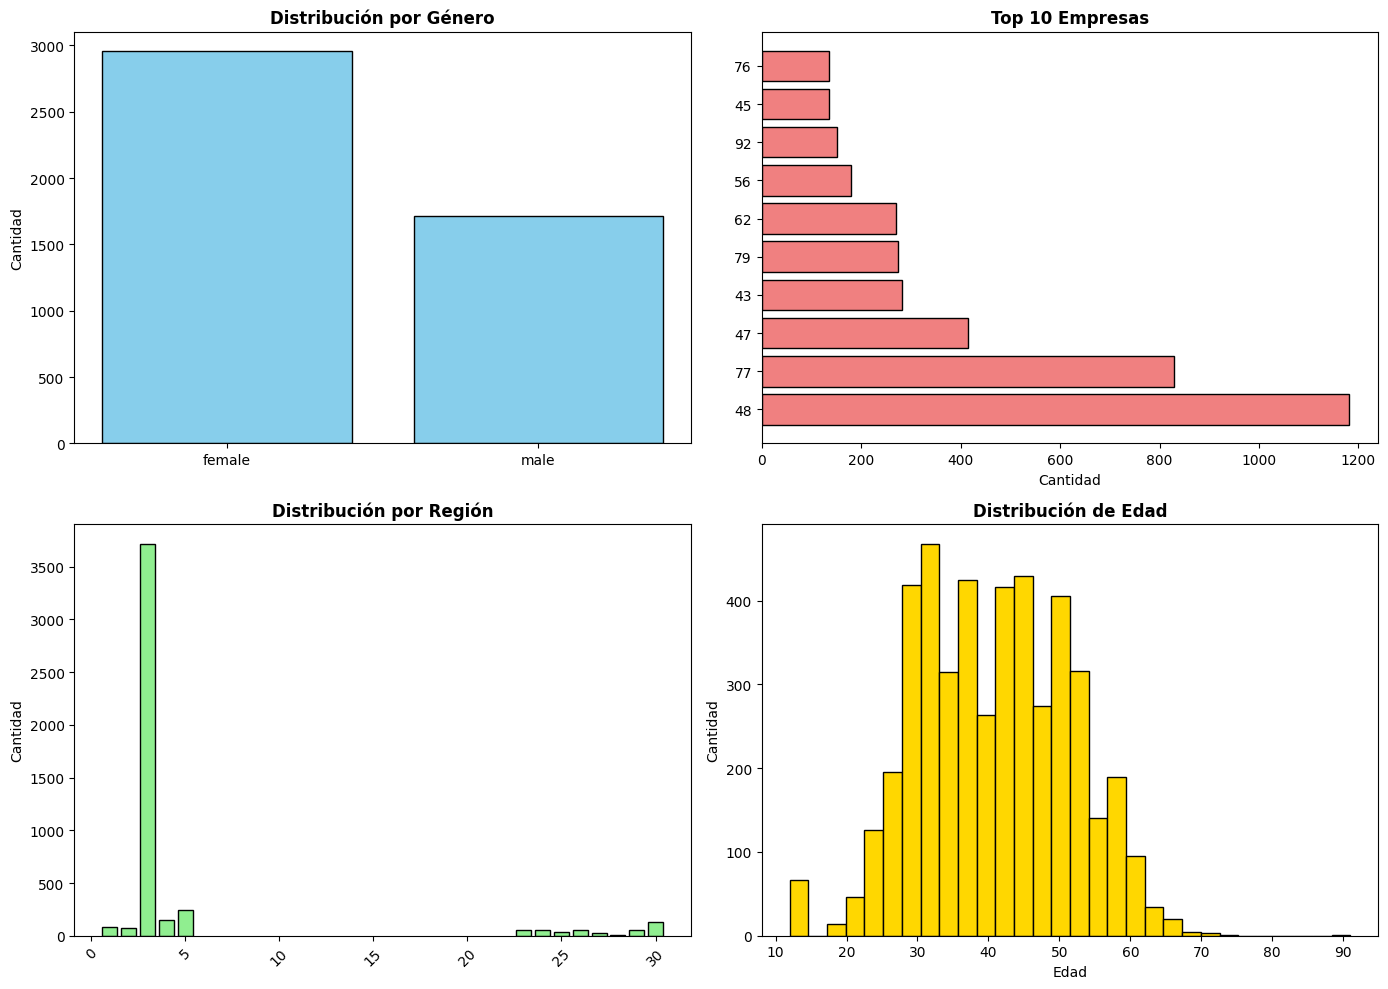

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Género
df_gender = df_user_full['gender'].value_counts()
axes[0, 0].bar(df_gender.index, df_gender.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución por Género', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Cantidad')

# Empresa
df_company = df_user_full['company'].value_counts().head(10)
axes[0, 1].barh(range(len(df_company)), df_company.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_yticks(range(len(df_company)))
axes[0, 1].set_yticklabels(df_company.index)
axes[0, 1].set_title('Top 10 Empresas', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cantidad')

# Región
df_region = df_user_full['region'].value_counts()
axes[1, 0].bar(df_region.index, df_region.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribución por Región', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].tick_params(axis='x', rotation=45)

# Edad (por histograma)
axes[1, 1].hist(df_user_full['age'].dropna(), bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribución de Edad', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Edad')
axes[1, 1].set_ylabel('Cantidad')

print("Edad mínima:", df_user_full['age'].min())
print("Edad máxima:", df_user_full['age'].max())

plt.tight_layout()
plt.show()

### Health Problems
Transformamos Problemas de Salud para pasar de identificadores categóricos a features binarios àra poder ser incluidos en algortimos de clustering numericos y mejorar interpretabilidad.

In [ ]:
# Transformación de healthProblems a variables binarias
health_map = {
    '20': 'Has_Diabetes',
    '21': 'Has_Colesterol',
    '22': 'Has_Tension',
    '23': 'Has_Hierro',
    '24': 'Has_Calcio'
}

def parse_health(x):
    if pd.isna(x) or str(x).strip() == '':
        return []
    # separa, limpia espacios y elimina duplicados
    items = [i.strip() for i in str(x).split(',') if i.strip() != '']
    return sorted(set(items))

# Normalizar healthProblems
df_user_full['healthProblems'] = df_user_full['healthProblems'].apply(parse_health)

# Crear columnas binarias
for code, col_name in health_map.items():
    df_user_full[col_name] = df_user_full['healthProblems'].apply(
        lambda x: 1 if code in x else 0
    )

# Número de problemas distintos por usuario
df_user_full['Num_HealthProblems'] = df_user_full[list(health_map.values())].sum(axis=1)

# Eliminar columna original/lista si no la necesitas
df_user_full = df_user_full.drop(columns=['healthProblems'], errors='ignore')


### Alergias
Transformamos Alergias para pasar de identificadores categóricos a features que cuente nº de alergias declaradas para poder ser incluidos en algortimos de clustering numericos y mejorar interpretabilidad.

In [ ]:
def parse_allergies(x):
    if pd.isna(x) or str(x).strip() == '':
        return []
    return list(set([i.strip() for i in str(x).split(',')]))

df_user_full['Num_Allergies'] = df_user_full['allergies'].apply(lambda x: len(parse_allergies(x)))

###Mindfulness
Comprobamos si el usuario consume contenido de Bienestar Emocional y le asignamos Has_Mindfulness como variable booleana.
A continuación quitamos las variables MindfulnessID y MindfulessCategory

In [ ]:
def has_mindfulness(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()
    return 1 if x != '' else 0

df_user_full['Has_Mindfulness'] = df_user_full['mindfulnessID'].apply(has_mindfulness)
df_user_full = df_user_full.drop(columns=['mindfulnessID', 'mindfulnessCategory'], errors='ignore')



### Análisis de textos
Hay varias columnas que presentan valores separados por '|', pudiendo ser campos multiselección.

#### `preferredWellnessArea` y `registeredActivity`

In [ ]:
# 1) Limpieza y parseo a lista de opciones por fila
def parse_options(x):
    if pd.isna(x):
        return []
    # Separar por | o , (multiselect serializado en distintos formatos)
    raw_items = re.split(r"[|,]", str(x))
    items = [i.strip().upper() for i in raw_items]
    # Elimina vacios y valores tipo null string
    items = [i for i in items if i not in ("", "NONE", "NAN", "NULL")]
    # Elimina duplicados manteniendo orden
    return list(dict.fromkeys(items))

tmp = df_user_full[["preferredWellnessArea"]].copy()
tmp["options"] = tmp["preferredWellnessArea"].apply(parse_options)
tmp["n_options"] = tmp["options"].apply(len)

# 2) Cobertura y calidad basica
print("=== Cobertura (df_user_full) ===")
print(f"Filas totales: {len(tmp)}")
print(f"Filas con valor no nulo original: {tmp['preferredWellnessArea'].notna().sum()}")
print(f"Filas con al menos 1 opcion valida: {(tmp['n_options'] > 0).sum()}")

print("\n=== Numero de opciones por fila ===")
print(tmp["n_options"].describe())

# 3) Frecuencia de cada opcion (explode)
exploded = tmp.explode("options")
exploded_valid = exploded[exploded["options"].notna() & (exploded["options"] != "")]

freq = exploded_valid["options"].value_counts()
freq_pct = (freq / len(tmp) * 100).round(2)

res_freq = pd.DataFrame({
    "count": freq,
    "% sobre filas totales": freq_pct
})
print("\n=== Frecuencia por opcion (Top 25) ===")
display(res_freq.head(25))

# 4) Top combinaciones (pares) dentro de una misma fila
pair_counter = Counter()
for opts in tmp["options"]:
    if len(opts) >= 2:
        for p in combinations(sorted(opts), 2):
            pair_counter[p] += 1

if pair_counter:
    pairs_df = (
        pd.DataFrame(
            [{"pair": " | ".join(k), "count": v} for k, v in pair_counter.items()]
        )
        .sort_values("count", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
else:
    pairs_df = pd.DataFrame(columns=["pair", "count"])

print("\n=== Top 20 pares de opciones que coocurren ===")
display(pairs_df)

# 5) Evidencia de delimitadores usados
contains_pipe = tmp["preferredWellnessArea"].fillna("").str.contains(r"\|", regex=True).sum()
contains_comma = tmp["preferredWellnessArea"].fillna("").str.contains(r",", regex=True).sum()
print("\n=== Delimitadores detectados en texto original ===")
print(f"Filas con '|': {contains_pipe}")
print(f"Filas con ',': {contains_comma}")

# 6) Filas raras para inspeccion manual (solo no nulas)
mask_raw = tmp["preferredWellnessArea"].notna()
mask_sospechosas = (
    mask_raw & (
        tmp["preferredWellnessArea"].str.contains(r"\|\s*\|", regex=True)
        | tmp["preferredWellnessArea"].str.contains(r",\s*,", regex=True)
        | tmp["preferredWellnessArea"].str.contains(r"\|\s*,|,\s*\|", regex=True)
    )
)
print("\n=== Ejemplos sospechosos (sin incluir NaN) ===")
display(tmp.loc[mask_sospechosas, ["preferredWellnessArea", "options"]].head(20))

=== Cobertura (df_user_full) ===
Filas totales: 4668
Filas con valor no nulo original: 70
Filas con al menos 1 opcion valida: 70

=== Numero de opciones por fila ===
count    4668.000000
mean        0.042845
std         0.501430
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.000000
Name: n_options, dtype: float64

=== Frecuencia por opcion (Top 25) ===


,count,% sobre filas totales
options,,
BREAKFAST,31,0.66
LUNCH,28,0.60
SNACK,23,0.49
AFTERNOON_SNACK,20,0.43
DINNER,19,0.41
EXERCISE_COMPLETED,16,0.34
STEPS,13,0.28
SLEEP,13,0.28
MEALS_COMPLETED,13,0.28



=== Top 20 pares de opciones que coocurren ===


,pair,count
0,BREAKFAST | SNACK,18
1,BREAKFAST | LUNCH,17
2,BREAKFAST | DINNER,14
3,AFTERNOON_SNACK | BREAKFAST,14
4,AFTERNOON_SNACK | LUNCH,14
5,AFTERNOON_SNACK | SNACK,14
6,LUNCH | SNACK,14
7,DINNER | SNACK,13
8,AFTERNOON_SNACK | DINNER,13
9,DINNER | LUNCH,13



=== Delimitadores detectados en texto original ===
Filas con '|': 5
Filas con ',': 32

=== Ejemplos sospechosos (sin incluir NaN) ===


,preferredWellnessArea,options


In [ ]:
# 1) Limpieza y parseo a lista de opciones por fila
def parse_options_activity(x):
    if pd.isna(x):
        return []
    # Separar por | o , (multiselect serializado en distintos formatos)
    raw_items = re.split(r"[|,]", str(x))
    items = [i.strip().upper() for i in raw_items]
    # Elimina vacios y valores tipo null string
    items = [i for i in items if i not in ("", "NONE", "NAN", "NULL")]
    # Elimina duplicados manteniendo orden
    return list(dict.fromkeys(items))

tmp = df_user_full[["registeredActivity"]].copy()
tmp["options"] = tmp["registeredActivity"].apply(parse_options_activity)
tmp["n_options"] = tmp["options"].apply(len)

# 2) Cobertura y calidad basica
print("=== Cobertura (df_user_full) ===")
print(f"Filas totales: {len(tmp)}")
print(f"Filas con valor no nulo original: {tmp['registeredActivity'].notna().sum()}")
print(f"Filas con al menos 1 opcion valida: {(tmp['n_options'] > 0).sum()}")

print("\n=== Numero de opciones por fila ===")
print(tmp["n_options"].describe())

# 3) Frecuencia de cada opcion (explode)
exploded = tmp.explode("options")
exploded_valid = exploded[exploded["options"].notna() & (exploded["options"] != "")]

freq = exploded_valid["options"].value_counts()
freq_pct = (freq / len(tmp) * 100).round(2)

res_freq = pd.DataFrame({
    "count": freq,
    "% sobre filas totales": freq_pct
})
print("\n=== Frecuencia por opcion (Top 25) ===")
display(res_freq.head(25))

# 4) Top combinaciones (pares) dentro de una misma fila
pair_counter = Counter()
for opts in tmp["options"]:
    if len(opts) >= 2:
        for p in combinations(sorted(opts), 2):
            pair_counter[p] += 1

if pair_counter:
    pairs_df = (
        pd.DataFrame(
            [{"pair": " | ".join(k), "count": v} for k, v in pair_counter.items()]
        )
        .sort_values("count", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
else:
    pairs_df = pd.DataFrame(columns=["pair", "count"])

print("\n=== Top 20 pares de opciones que coocurren ===")
display(pairs_df)

# 5) Evidencia de delimitadores usados
contains_pipe = tmp["registeredActivity"].fillna("").str.contains(r"\|", regex=True).sum()
contains_comma = tmp["registeredActivity"].fillna("").str.contains(r",", regex=True).sum()
print("\n=== Delimitadores detectados en texto original ===")
print(f"Filas con '|': {contains_pipe}")
print(f"Filas con ',': {contains_comma}")

# 6) Filas raras para inspeccion manual (solo no nulas)
mask_raw = tmp["registeredActivity"].notna()
mask_sospechosas = (
    mask_raw & (
        tmp["registeredActivity"].str.contains(r"\|\s*\|", regex=True)
        | tmp["registeredActivity"].str.contains(r",\s*,", regex=True)
        | tmp["registeredActivity"].str.contains(r"\|\s*,|,\s*\|", regex=True)
    )
)
print("\n=== Ejemplos sospechosos (sin incluir NaN) ===")
display(tmp.loc[mask_sospechosas, ["registeredActivity", "options"]].head(20))

=== Cobertura (df_user_full) ===
Filas totales: 4668
Filas con valor no nulo original: 37
Filas con al menos 1 opcion valida: 37

=== Numero de opciones por fila ===
count    4668.000000
mean        0.016495
std         0.256783
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.000000
Name: n_options, dtype: float64

=== Frecuencia por opcion (Top 25) ===


,count,% sobre filas totales
options,,
WALKING,23,0.49
OTHER,10,0.21
RUNNING,8,0.17
CYCLING,6,0.13
TRACK_AND_FIELD,4,0.09
TENNIS,3,0.06
SOCCER,2,0.04
ELLIPTICAL,2,0.04
TRAINING,2,0.04



=== Top 20 pares de opciones que coocurren ===


,pair,count
0,RUNNING | WALKING,7
1,OTHER | WALKING,6
2,CYCLING | WALKING,5
3,CYCLING | RUNNING,4
4,CYCLING | OTHER,4
5,RUNNING | TRACK_AND_FIELD,3
6,OTHER | RUNNING,3
7,CYCLING | TRACK_AND_FIELD,2
8,CYCLING | TENNIS,2
9,OTHER | TENNIS,2



=== Delimitadores detectados en texto original ===
Filas con '|': 5
Filas con ',': 15

=== Ejemplos sospechosos (sin incluir NaN) ===


,registeredActivity,options


#### Análisis de `preferredWellnessArea` y `registeredActivity`
Con los datos existentes en el dataset se acuerda eliminar estas variables, pues actualmente no existen suficientes datos para que las columnas sean relevantes.
No obstante, se deja el código del análisis íntegro por si en un futuro se tuvieran datos suficientes y se volviera a analizar.

#### `dislikeRecipes` y `likeRecipes`

In [ ]:
# 1) Limpieza y parseo a lista de opciones por fila
def parse_options_dislike(x):
    if pd.isna(x):
        return []
    # Separar por | o , (multiselect serializado en distintos formatos)
    raw_items = re.split(r"[|,]", str(x))
    items = [i.strip().upper() for i in raw_items]
    # Elimina vacios y valores tipo null string
    items = [i for i in items if i not in ("", "NONE", "NAN", "NULL")]
    # Elimina duplicados manteniendo orden
    return list(dict.fromkeys(items))

tmp = df_user_full[["dislikeRecipes"]].copy()
tmp["options"] = tmp["dislikeRecipes"].apply(parse_options_dislike)
tmp["n_options"] = tmp["options"].apply(len)

# 2) Cobertura y calidad basica
print("=== Cobertura (df_user_full) ===")
print(f"Filas totales: {len(tmp)}")
print(f"Filas con valor no nulo original: {tmp['dislikeRecipes'].notna().sum()}")
print(f"Filas con al menos 1 opcion valida: {(tmp['n_options'] > 0).sum()}")

print("\n=== Numero de opciones por fila ===")
print(tmp["n_options"].describe())

# 3) Frecuencia de cada opcion (explode)
exploded = tmp.explode("options")
exploded_valid = exploded[exploded["options"].notna() & (exploded["options"] != "")]

if len(exploded_valid) > 0:
    freq = exploded_valid["options"].value_counts()
    freq_pct = (freq / len(tmp) * 100).round(2)

    res_freq = pd.DataFrame({
        "count": freq,
        "% sobre filas totales": freq_pct
    })
    print("\n=== Frecuencia por opcion (Top 25) ===")
    display(res_freq.head(25))
else:
    print("\n=== Frecuencia por opcion (Top 25) ===")
    print("No hay datos válidos para mostrar")

# 4) Top combinaciones (pares) dentro de una misma fila
pair_counter = Counter()
for opts in tmp["options"]:
    if len(opts) >= 2:
        for p in combinations(sorted(opts), 2):
            pair_counter[p] += 1

if pair_counter:
    pairs_df = (
        pd.DataFrame(
            [{"pair": " | ".join(k), "count": v} for k, v in pair_counter.items()]
        )
        .sort_values("count", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
else:
    pairs_df = pd.DataFrame(columns=["pair", "count"])

print("\n=== Top 20 pares de opciones que coocurren ===")
display(pairs_df)

# 5) Evidencia de delimitadores usados
contains_pipe = tmp["dislikeRecipes"].fillna("").str.contains(r"\|", regex=True).sum()
contains_comma = tmp["dislikeRecipes"].fillna("").str.contains(r",", regex=True).sum()
print("\n=== Delimitadores detectados en texto original ===")
print(f"Filas con '|': {contains_pipe}")
print(f"Filas con ',': {contains_comma}")

# 6) Filas raras para inspeccion manual (solo no nulas)
mask_raw = tmp["dislikeRecipes"].notna()
mask_sospechosas = (
    mask_raw & (
        tmp["dislikeRecipes"].str.contains(r"\|\s*\|", regex=True)
        | tmp["dislikeRecipes"].str.contains(r",\s*,", regex=True)
        | tmp["dislikeRecipes"].str.contains(r"\|\s*,|,\s*\|", regex=True)
    )
)
print("\n=== Ejemplos sospechosos (sin incluir NaN) ===")
display(tmp.loc[mask_sospechosas, ["dislikeRecipes", "options"]].head(20))

=== Cobertura (df_user_full) ===
Filas totales: 4668
Filas con valor no nulo original: 356
Filas con al menos 1 opcion valida: 356

=== Numero de opciones por fila ===
count    4668.000000
mean        0.261568
std         1.537868
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        52.000000
Name: n_options, dtype: float64

=== Frecuencia por opcion (Top 25) ===


,count,% sobre filas totales
options,,
CAFÉ CON LECHE,59,1.26
CAFÉ DESCAFEINADO,41,0.88
TÉ,33,0.71
CIRUELAS,31,0.66
BOL DE CEREALES,30,0.64
TOSTA DE AGUACATE Y TOMATE,29,0.62
FRESAS,21,0.45
TÉ CON LECHE,19,0.41
ZUMO DE POMELO,19,0.41



=== Top 20 pares de opciones que coocurren ===


,pair,count
0,TOMATE Y KIWI | TOSTA DE PEPINO,18
1,CAFÉ CON LECHE | CIRUELAS,11
2,CIRUELAS | MELÓN,10
3,CAFÉ CON LECHE | CAFÉ DESCAFEINADO,10
4,CREMA DE PATATAS | PUERROS Y ZANAHORIAS,9
5,ALBARICOQUES | FRESAS,9
6,CAFÉ DESCAFEINADO | TÉ,9
7,CAFÉ CON LECHE | TOMATE Y KIWI,8
8,CAFÉ CON LECHE | TOSTA DE PEPINO,8
9,BOL DE CEREALES | CAFÉ CON LECHE,7



=== Delimitadores detectados en texto original ===
Filas con '|': 0
Filas con ',': 198

=== Ejemplos sospechosos (sin incluir NaN) ===


,dislikeRecipes,options


#### dislikeRecipes Analysis

In [ ]:
# 1) Limpieza y parseo a lista de opciones por fila
def parse_options_recipes(x):
    if pd.isna(x):
        return []
    # Separar por | o , (multiselect serializado en distintos formatos)
    raw_items = re.split(r"[|,]", str(x))
    items = [i.strip().upper() for i in raw_items]
    # Elimina vacios y valores tipo null string
    items = [i for i in items if i not in ("", "NONE", "NAN", "NULL")]
    # Elimina duplicados manteniendo orden
    return list(dict.fromkeys(items))

tmp = df_user_full[["likeRecipes"]].copy()
tmp["options"] = tmp["likeRecipes"].apply(parse_options_recipes)
tmp["n_options"] = tmp["options"].apply(len)

# 2) Cobertura y calidad basica
print("=== Cobertura (df_user_full) ===")
print(f"Filas totales: {len(tmp)}")
print(f"Filas con valor no nulo original: {tmp['likeRecipes'].notna().sum()}")
print(f"Filas con al menos 1 opcion valida: {(tmp['n_options'] > 0).sum()}")

print("\n=== Numero de opciones por fila ===")
print(tmp["n_options"].describe())

# 3) Frecuencia de cada opcion (explode)
exploded = tmp.explode("options")
exploded_valid = exploded[exploded["options"].notna() & (exploded["options"] != "")]

if len(exploded_valid) > 0:
    freq = exploded_valid["options"].value_counts()
    freq_pct = (freq / len(tmp) * 100).round(2)

    res_freq = pd.DataFrame({
        "count": freq,
        "% sobre filas totales": freq_pct
    })
    print("\n=== Frecuencia por opcion (Top 25) ===")
    display(res_freq.head(25))
else:
    print("\n=== Frecuencia por opcion (Top 25) ===")
    print("No hay datos válidos para mostrar")

# 4) Top combinaciones (pares) dentro de una misma fila
pair_counter = Counter()
for opts in tmp["options"]:
    if len(opts) >= 2:
        for p in combinations(sorted(opts), 2):
            pair_counter[p] += 1

if pair_counter:
    pairs_df = (
        pd.DataFrame(
            [{"pair": " | ".join(k), "count": v} for k, v in pair_counter.items()]
        )
        .sort_values("count", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
else:
    pairs_df = pd.DataFrame(columns=["pair", "count"])

print("\n=== Top 20 pares de opciones que coocurren ===")
display(pairs_df)

# 5) Evidencia de delimitadores usados
contains_pipe = tmp["likeRecipes"].fillna("").str.contains(r"\|", regex=True).sum()
contains_comma = tmp["likeRecipes"].fillna("").str.contains(r",", regex=True).sum()
print("\n=== Delimitadores detectados en texto original ===")
print(f"Filas con '|': {contains_pipe}")
print(f"Filas con ',': {contains_comma}")

# 6) Filas raras para inspeccion manual (solo no nulas)
mask_raw = tmp["likeRecipes"].notna()
mask_sospechosas = (
    mask_raw & (
        tmp["likeRecipes"].str.contains(r"\|\s*\|", regex=True)
        | tmp["likeRecipes"].str.contains(r",\s*,", regex=True)
        | tmp["likeRecipes"].str.contains(r"\|\s*,|,\s*\|", regex=True)
    )
)
print("\n=== Ejemplos sospechosos (sin incluir NaN) ===")
display(tmp.loc[mask_sospechosas, ["likeRecipes", "options"]].head(20))

=== Cobertura (df_user_full) ===
Filas totales: 4668
Filas con valor no nulo original: 643
Filas con al menos 1 opcion valida: 643

=== Numero de opciones por fila ===
count    4668.000000
mean        1.044344
std         8.168383
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       399.000000
Name: n_options, dtype: float64

=== Frecuencia por opcion (Top 25) ===


,count,% sobre filas totales
options,,
CAFÉ CON LECHE,252,5.40
TOSTA DE AGUACATE Y TOMATE,108,2.31
TOSTADAS CON RODAJAS DE TOMATE,91,1.95
ORÉGANO Y ACEITE DE OLIVA VIRGEN,91,1.95
MANZANA,69,1.48
TÉ,64,1.37
BOL DE CEREALES,64,1.37
PLÁTANO,60,1.29
MANDARINA,58,1.24



=== Top 20 pares de opciones que coocurren ===


,pair,count
0,ORÉGANO Y ACEITE DE OLIVA VIRGEN | TOSTADAS CO...,91
1,CAFÉ CON LECHE | TOSTA DE AGUACATE Y TOMATE,51
2,CREMA DE PATATAS | PUERROS Y ZANAHORIAS,42
3,FRESAS | MANDARINA,33
4,ACOMPAÑADO DE MANGO | TOSTADAS CON AGUACATE Y ...,32
5,MANZANA | PIÑA,30
6,CAFÉ CON LECHE | PLÁTANO,30
7,CAFÉ CON LECHE | TOSTADAS CON RODAJAS DE TOMATE,29
8,CAFÉ CON LECHE | ORÉGANO Y ACEITE DE OLIVA VIRGEN,29
9,BOL DE CEREALES | CAFÉ CON LECHE,29



=== Delimitadores detectados en texto original ===
Filas con '|': 0
Filas con ',': 439

=== Ejemplos sospechosos (sin incluir NaN) ===


,likeRecipes,options


#### likeRecipes Analysis

Aquí exportamos los datos para tener un registro que sea único por usuario a un excel de salida que será la entrada para la siguiente fase (Clustering/PCA).

Se acuerdan quitar estas variables por cero o poca varianza, no representan comportamiento de salud o no aportar al modelo: nutritionPlanAdherence, userID, physicallyActiveFlag, company, department, region antes de realizar el export

In [ ]:
# Eliminación de variables que no representan comportamiento de salud, cero o poca varianza...
cols_to_drop = [
    'nutritionPlanAdherence',
    'physicallyActiveFlag',
    'company',
    'department',
    'region',
    'preferredWellnessArea',
    'registeredActivity',
    'challengeRanking',
    'cardiovascularRisk',
    'mindfullnessID',
    'activitySource',
    'preferredContentFormat',
    'caloriesBurned',
    'distanceKm',
    'platformAccess',
    'platformAccessFrequency',
    'restMinutes_clean',
    'totalDailySteps_clean',
    'fitnessPlanAdherence',
    'activityDuration',
    'activitySource',
    'discoverCategory',
    'sleepDays'
]


# Eliminar solo si existen (robusto)
cols_to_drop = [c for c in cols_to_drop if c in df_user_full.columns]
df_user_full = df_user_full.drop(columns=cols_to_drop)
df_user_full = df_user_full.round(2)
df_user_full.to_csv("df_user_full_procesado.csv", sep=';', decimal=',', index=False, encoding='utf-8-sig')

print("Dataset exportado correctamente")
print("Shape final:", df_user_full.shape)

Dataset exportado correctamente
Shape final: (4668, 39)
